In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import numpy as np

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.modeling.sarima_model import SARIMAModel
from backend.modeling.prophet_model import ProphetModel
from backend.modeling.xgboost_model import XGBoostModel
from sklearn.linear_model import LinearRegression

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
water_engineered_path = PATHS['engineered_data'] / 'water_engineered.parquet'
df = pd.read_parquet(water_engineered_path)
df.head()

,date,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
0,1988-01-05,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,103.0,NaN,1
1,1988-01-12,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,12,0,103.0,NaN,NaN,NaN,NaN,103.0,0.0,2
2,1988-01-19,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,19,0,103.0,103.0,NaN,NaN,NaN,103.0,0.0,3
3,1988-01-26,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,26,0,103.0,103.0,103.0,NaN,NaN,103.0,0.0,4
4,1988-02-02,103.0,103.0,NaN,cordoba,andalucia,1,1988,2,2,0,103.0,103.0,103.0,103.0,NaN,103.0,0.0,5


In [3]:
# Searching for reservoirs that have data from 2024-09-24
reservoirs_2024 = df[df['date'] == '2024-09-24']['id'].unique()
len(reservoirs_2024)

374

In [4]:
# Deleting all the reservoirs that don't have data from 2024-09-24
df = df[df['id'].isin(reservoirs_2024)]

In [5]:
def prepare_data(df, reservoir_id):
    df_res = df[df['id'] == reservoir_id].copy()
    df_res = df_res.sort_values('date')

    capacity = df[df['id'] == reservoir_id]['capacity'].values[0]

    # Set date as index
    series = df_res.set_index('date')['storage']
    length = len(series)
    years = min(13, length // 52) - 1 # At most we get 10 years of data

    # Train/test split: last 52 weeks as test
    train_series = series.iloc[-(52*(years+1)):-52] # 'years' years

    train_stacking_index = train_series[-(52*(years-4)):].index
    # Create a dataframe with train_index as index
    train_stacking = pd.DataFrame(index=train_stacking_index)
    train_stacking['storage'] = train_series[-(52*(years-4)):] # 'years'-4 years, as the first 4 are for training sarima and prophet
    train_stacking['sarima_prediction'] = np.nan
    train_stacking['prophet_prediction'] = np.nan

    test_stacking = pd.DataFrame(index=series.iloc[-52:].index)
    test_stacking['storage'] = series.iloc[-52:] # 1 year
    test_stacking['sarima_prediction'] = np.nan
    test_stacking['prophet_prediction'] = np.nan

    return train_series, train_stacking, test_stacking, capacity, years

In [6]:
def cv_sarima(train_sarima_prophet, train, test, years, capacity):
    for i in range(years-4):
        sarima_model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
        sarima_model.fit(train_sarima_prophet.iloc[(52*i):(52*(i+4))])
        sarima_test_pred = sarima_model.predict(steps=52)
        mask = sarima_test_pred > capacity
        sarima_test_pred[mask] = capacity
        train.iloc[(52*i):(52*(i+1)), train.columns.get_loc('sarima_prediction')] = sarima_test_pred

    # Predicting SARIMA for test data
    sarima_model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
    sarima_model.fit(train_sarima_prophet[-(52*4):])
    sarima_test_pred = sarima_model.predict(steps=52)
    mask = sarima_test_pred > capacity
    sarima_test_pred[mask] = capacity
    sarima_test_pred.index = test.index

    test['sarima_prediction'] = sarima_test_pred

    return train, test


In [7]:
def cv_prophet(train_sarima_prophet, train, test, years, capacity):
    for i in range(years-4):
        prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
        prophet_model.fit(train_sarima_prophet.iloc[(52*i):(52*(i+4))])
        prophet_test_pred = prophet_model.predict(steps=52)
        mask = prophet_test_pred > capacity
        prophet_test_pred[mask] = capacity
        train.iloc[(52*i):(52*(i+1)), train.columns.get_loc('prophet_prediction')] = prophet_test_pred

    # Predicting prophet for test data
    prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
    prophet_model.fit(train_sarima_prophet[-(52*4):])
    prophet_test_pred = prophet_model.predict(steps=52)
    mask = prophet_test_pred > capacity
    prophet_test_pred[mask] = capacity
    prophet_test_pred.index = test.index

    test['prophet_prediction'] = prophet_test_pred

    return train, test


In [8]:
def cv_xgboost(train, test, train_series_xgboost, years_training, years_training_xgboost, capacity):
    def predict_next_year(model, X, years_training_xgboost):
        predictions = []
        for week in range(1, 53):
            X_step = X.copy()[-(52*years_training_xgboost):]
            next_year_predictions = pd.concat([X_step, test], axis=0)
            X_step['sarima_prediction'] = next_year_predictions['sarima_prediction'].shift(-week).iloc[:52*years_training_xgboost]
            X_step['prophet_prediction'] = next_year_predictions['prophet_prediction'].shift(-week).iloc[:52*years_training_xgboost]
            storage_one_year_ago = X_step['storage'][-52]
            difference = storage_one_year_ago - X_step['storage'].iloc[-1]
            last_row = X_step.iloc[-1]
            X_step['next_storage_value'] = X_step['storage'].shift(-week)
            X_step = X_step.iloc[:-52]
            
            last_row['storage'] = last_row['storage'] + difference
            last_row['sarima_prediction'] = last_row['sarima_prediction'] + difference
            last_row['prophet_prediction'] = last_row['prophet_prediction'] + difference
            
            model.fit(X_step)
            
            # Generate forecasts for 52 steps
            prediction = model.predict(last_row.to_frame().T)
            predictions.append(prediction[0]-difference)

        return pd.Series(predictions, dtype=float)
    
    # Create and train XGBoost model
    model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)

    for i in range(years_training):
        xgboost_test_pred = predict_next_year(model, train_series_xgboost.iloc[i*52:(i+years_training_xgboost)*52], years_training_xgboost)
        mask = xgboost_test_pred > capacity
        xgboost_test_pred[mask] = capacity
        train.iloc[(52*i):(52*(i+1)), train.columns.get_loc('xgboost_prediction')] = xgboost_test_pred.values.astype('float64')

    xgboost_test_pred = predict_next_year(model, train_series_xgboost.iloc[-(52*years_training_xgboost):], years_training_xgboost)
    mask = xgboost_test_pred > capacity
    xgboost_test_pred[mask] = capacity
    xgboost_test_pred.index = test.index

    test['xgboost_prediction'] = xgboost_test_pred.astype('float64')
    train['xgboost_prediction'] = train['xgboost_prediction'].astype(float)

    return train, test

In [8]:
df[df['autonomous_community'] == 'andalucia']['id'].unique()

array([  1,   3,   5,   6,   9,  11,  60,  61,  64,  65,  69,  70, 100,
       108, 113, 137, 155, 156, 159, 160, 161, 162, 164, 171, 203, 204,
       205, 209, 212, 226, 235, 237, 240, 241, 242, 277, 283, 285, 286,
       287, 288, 300, 324, 325, 326, 328, 367, 369, 371, 375, 376, 402,
       403, 404, 405, 408, 409, 413, 471, 474, 475, 476, 478, 512, 513,
       514, 518, 523, 524, 525, 562, 563, 564, 569, 570, 571, 615, 618,
       621, 623, 624, 658, 659, 660, 665, 672, 692, 693, 695, 704, 714],
      dtype=int64)

# Important

In [49]:
# Define a lock to access the next_year DataFrame
import threading
next_year_lock = threading.Lock()

def predict_one_year(reservoir_id, years_training, plotting=True):

    next_year_predictions_path = PATHS['processed_data'] / 'next_year_predictions.parquet'
    next_year_predictions = pd.read_parquet(next_year_predictions_path)

    if f'id_{reservoir_id}' in next_year_predictions.columns:
        return next_year_predictions[f'id_{reservoir_id}']
    
    else:
        # Reuse existing preparation and training
        train_sarima_prophet, train, test, capacity, years = prepare_data(df, reservoir_id)
        train, test = cv_sarima(train_sarima_prophet, train, test, years, capacity)
        train, test = cv_prophet(train_sarima_prophet, train, test, years, capacity)

        # Prepare data for XGBoost
        train_series_xgboost = train.copy()
        train = train[-(52*years_training):]
        train.loc[:, 'storage'] = train['storage'].astype(float)
        train.loc[:, 'sarima_prediction'] = train['sarima_prediction'].astype(float)
        train.loc[:, 'prophet_prediction'] = train['prophet_prediction'].astype(float)
        train['xgboost_prediction'] = np.nan

        test.loc[:, 'storage'] = test['storage'].astype(float)
        test.loc[:, 'sarima_prediction'] = test['sarima_prediction'].astype(float)
        test.loc[:, 'prophet_prediction'] = test['prophet_prediction'].astype(float)
        test['xgboost_prediction'] = np.nan

        years_training_xgboost = (len(train_series_xgboost) // 52) - years_training
        train, test = cv_xgboost(train, test, train_series_xgboost, years_training, years_training_xgboost, capacity)

        # Train the linear regression stacking model
        X_train = train[['sarima_prediction', 'prophet_prediction', 'xgboost_prediction']].copy()
        y_train = train['storage'].copy()
        stacking_model = LinearRegression()
        stacking_model.fit(X_train, y_train)



        # Create next year index
        last_week = test.iloc[-1].name
        start = last_week
        weekly = pd.date_range(start=start, periods=53, freq='7D')
        next_year_index = weekly[1:]
        next_year = pd.DataFrame(index=next_year_index)



        # 1. SARIMA
        full_series = df[df['id'] == reservoir_id].set_index('date')['storage'].sort_index()
        sarima_model_next = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
        sarima_model_next.fit(full_series[-(52*4):])  # Last 4 years
        sarima_next_pred = sarima_model_next.predict(steps=52)
        mask = sarima_next_pred > capacity
        sarima_next_pred[mask] = capacity
        sarima_next_pred.index = next_year_index
        next_year['sarima_prediction'] = sarima_next_pred

        # 2. PROPHET
        prophet_model_next = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
        prophet_model_next.fit(full_series[-(52*4):])  # Last 4 years
        prophet_next_pred = prophet_model_next.predict(steps=52)
        mask = prophet_next_pred > capacity
        prophet_next_pred[mask] = capacity
        prophet_next_pred.index = next_year_index
        next_year['prophet_prediction'] = prophet_next_pred

        # 3. XGBOOST
        def predict_next_year_xgboost(model, historical_data, years_training_xgboost, next_year_index):
            predictions = []
            # Use the full historical data including test predictions as features
            full_historical = pd.concat([historical_data, test], axis=0)
            
            for week in range(1, 53):
                # Get the training window
                X_step = full_historical.copy()[-(52*years_training_xgboost):]
                
                # For future predictions, we need to shift our features appropriately
                # We'll use the predicted values from SARIMA and Prophet for this future week
                last_row = X_step.iloc[-1].copy()
                
                # Set the features for this prediction step
                last_row['storage'] = full_historical['storage'].iloc[-1]  # Last known storage
                last_row['sarima_prediction'] = sarima_next_pred.iloc[week-1]  # SARIMA prediction for this week
                last_row['prophet_prediction'] = prophet_next_pred.iloc[week-1]  # Prophet prediction for this week
                
                # Create target variable for training (shift by the week we're predicting)
                X_step['next_storage_value'] = X_step['storage'].shift(-1)
                X_step = X_step.iloc[:-1]  # Remove last row since it has no target
                
                # Train model on this window
                model.fit(X_step)
                
                # Predict
                prediction = model.predict(last_row.to_frame().T)
                predictions.append(prediction[0])
                
                # Update the historical data with this prediction for next iteration
                new_row = pd.DataFrame({
                    'storage': [prediction[0]], 
                    'sarima_prediction': [sarima_next_pred.iloc[week-1]], 
                    'prophet_prediction': [prophet_next_pred.iloc[week-1]]
                }, index=[next_year_index[week-1]])
                full_historical = pd.concat([full_historical, new_row])
            
            return pd.Series(predictions, index=next_year_index, dtype=float)

        # Create XGBoost model and predict
        xgb_model_next = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
        xgb_next_pred = predict_next_year_xgboost(xgb_model_next, train_series_xgboost, years_training_xgboost, next_year_index)
        mask = xgb_next_pred > capacity
        xgb_next_pred[mask] = capacity
        next_year['xgboost_prediction'] = xgb_next_pred

        # 4. LINEAR REGRESSION
        X_next = next_year[['sarima_prediction', 'prophet_prediction', 'xgboost_prediction']].copy()
        lr_next_pred = stacking_model.predict(X_next)
        next_year['LR_prediction'] = lr_next_pred

        # 5. WEIGHTED AVERAGE
        next_year['full_weighted_average'] = next_year['prophet_prediction'] * 0.15 + next_year['sarima_prediction'] * 0.25 + next_year['xgboost_prediction'] * 0.25 + next_year['LR_prediction'] * 0.35

        # Define a lock to access the next_year DataFrame
        next_year_lock = threading.Lock()

        with next_year_lock:
            path = PATHS['processed_data'] / 'next_year_predictions.parquet'
            next_year_predictions = pd.read_parquet(next_year_predictions_path)
            next_year_predictions[f'id_{reservoir_id}'] = next_year['full_weighted_average']
            next_year_predictions.to_parquet(path, index=True)

        # COMPREHENSIVE PLOT
        def plot_historical_and_next_year(train, test, next_year, reservoir_id):
            plt.figure(figsize=(20, 10))

            train = pd.concat([train, test], axis=0)  # Combine train and test for plotting
            
            # Plot historical training data
            plt.plot(train.index, train['storage'], label='Known evolution', color='blue', linewidth=2, alpha=0.8)
            
            # Plot next year predictions
            plt.plot(next_year.index, next_year['full_weighted_average'], label='Next Year Prediction', 
                    color='black', linestyle='-', linewidth=3, alpha=0.9)
            
            # Add vertical lines for transitions

            plt.axvline(next_year.index[0], color='red', linestyle='--', alpha=0.6, label='Known / Prediction Split')

            # Formatting
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.title(f'Reservoir {reservoir_id}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Storage', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        if plotting:
            # Call the plotting function
            plot_historical_and_next_year(train, test, next_year, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

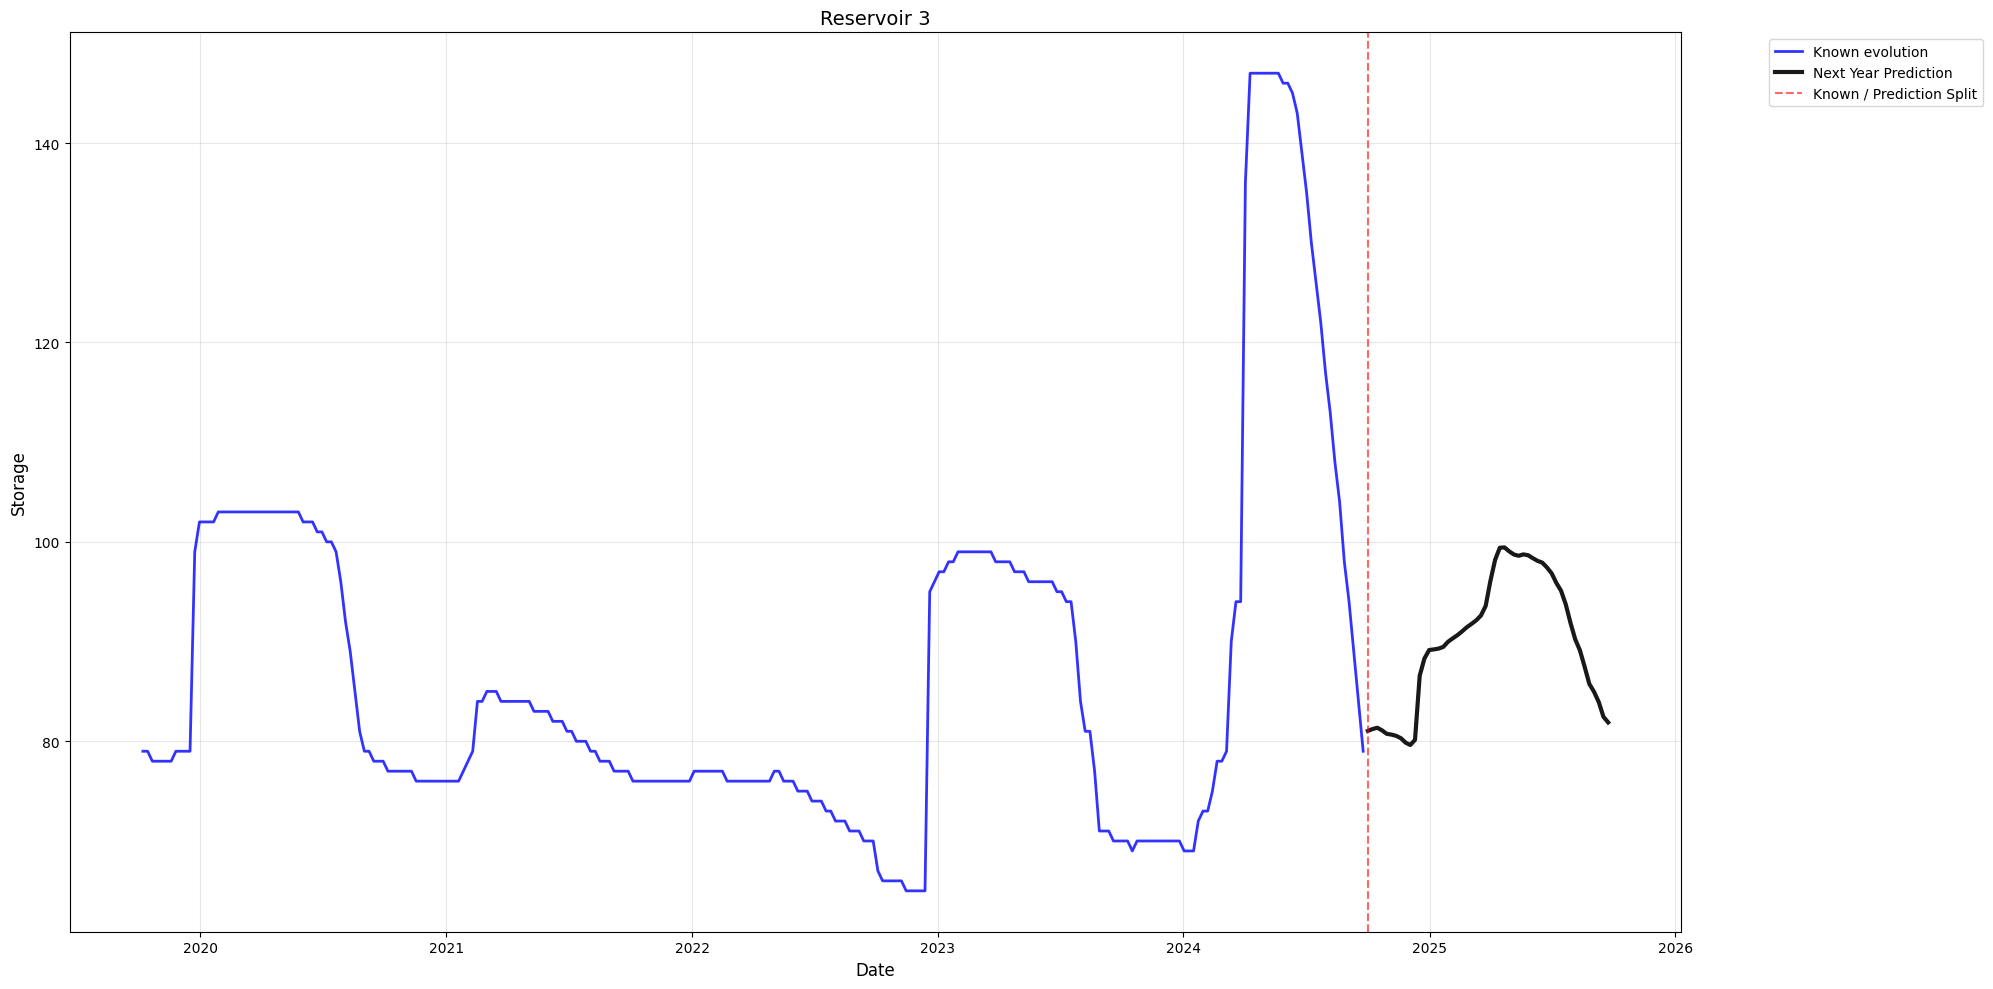

In [80]:
predict_one_year(3,4)

# Reading a parquet

In [98]:
path = PATHS['processed_data'] / 'next_year_predictions.parquet'
read_df = pd.read_parquet(path)
read_df

,id_9,id_241,id_288,id_478,id_569,id_704,id_113,id_212,id_240,id_242,id_326,id_328,id_375,id_571,id_623,id_624
2024-10-01,24.000000,4.000000,25.000000,12.000000,32.000000,5.000000,27.000000,25.000000,3.000000,30.000000,18.000000,139.000000,90.000000,6.000000,13.000000,46.000000
2024-10-08,23.367174,3.739510,23.247850,11.241825,31.114505,5.035830,26.009747,23.147980,2.864101,29.332606,17.705750,133.954399,87.752136,5.860489,12.757902,45.073878
2024-10-15,23.008188,3.730655,21.299127,10.538347,29.730690,5.044032,25.331013,22.755719,2.765643,28.575131,16.877223,130.546135,85.863477,5.491457,12.847115,44.407259
2024-10-22,22.986373,3.707034,20.324210,10.091056,28.703733,5.040350,25.058914,22.531331,2.699903,27.925427,16.457903,129.382539,84.769342,5.404766,12.846680,44.297686
2024-10-29,22.909292,3.302028,19.884642,9.859344,27.911442,4.997428,24.896860,22.483103,2.664024,27.676867,16.033248,129.020704,83.933202,5.401935,12.823727,44.396300
2024-11-05,22.829458,3.289854,19.645812,9.793572,27.605383,4.864592,24.904858,22.357875,2.649481,27.370755,15.882052,128.428529,83.483256,5.464193,12.763966,44.560704
2024-11-12,22.653679,3.284880,19.284580,9.653620,26.822372,4.725496,24.842293,22.241258,2.694170,27.260303,15.797928,127.372404,82.898723,5.509643,12.711774,44.584788
2024-11-19,22.366365,3.286651,19.015299,9.372592,25.847938,4.434893,24.689690,22.353146,2.748408,26.430546,15.582559,126.487322,82.573847,5.479270,12.705033,44.760106
2024-11-26,22.209069,3.290222,18.702572,9.206594,24.896940,4.265173,24.588516,21.774068,2.782247,25.642671,15.360871,125.665848,81.991662,5.404761,12.697708,44.814496
2024-12-03,21.932368,3.289801,18.393789,9.287680,24.329746,4.202239,24.749328,21.310128,2.731113,24.979993,15.328813,125.581040,81.572312,5.380573,12.685334,44.973903


# Saving a parquet

In [ ]:
DON'T EXECUTE

dataframe = pd.DataFrame(index=next_year.index)
path = PATHS['processed_data'] / 'next_year_predictions.parquet'
path.parent.mkdir(parents=True, exist_ok=True)
dataframe.to_parquet(path, index=True)

In [69]:
df[df['id']==3]

,date,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
1147,1988-01-05,0.0,247.0,719.55,jaen,andalucia,3,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,1
1148,1988-01-12,0.0,247.0,719.55,jaen,andalucia,3,1988,1,12,0,0.0,NaN,NaN,NaN,NaN,0.00,0.000000,2
1149,1988-01-19,0.0,247.0,719.55,jaen,andalucia,3,1988,1,19,0,0.0,0.0,NaN,NaN,NaN,0.00,0.000000,3
1150,1988-01-26,0.0,247.0,719.55,jaen,andalucia,3,1988,1,26,0,0.0,0.0,0.0,NaN,NaN,0.00,0.000000,4
1151,1988-02-02,0.0,247.0,719.55,jaen,andalucia,3,1988,2,2,0,0.0,0.0,0.0,0.0,NaN,0.00,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3059,2024-08-27,98.0,247.0,719.55,jaen,andalucia,3,2024,8,27,0,104.0,108.0,113.0,117.0,71.0,105.75,6.344289,35
3060,2024-09-03,94.0,247.0,719.55,jaen,andalucia,3,2024,9,3,0,98.0,104.0,108.0,113.0,71.0,101.00,6.218253,36
3061,2024-09-10,89.0,247.0,719.55,jaen,andalucia,3,2024,9,10,0,94.0,98.0,104.0,108.0,71.0,96.25,6.344289,37
3062,2024-09-17,84.0,247.0,719.55,jaen,andalucia,3,2024,9,17,0,89.0,94.0,98.0,104.0,70.0,91.25,6.075909,38


374

In [68]:
len(df[df['date'].dt.year == 2023]['id'].unique())

374

In [72]:
df[df['date'] == '2024-09-24']['id'].unique()

array([  3,   5,   9,  11,  12,  14,  18,  19,  22,  24,  26,  29,  32,
        34,  36,  38,  40,  42,  44,  46,  47,  48,  50,  51,  52,  54,
        55,  58,  60,  61,  65,  69,  70,  71,  72,  74,  75,  77,  78,
        80,  89,  91,  92,  94,  95,  96,  97,  98, 100, 108, 109, 113,
       114, 115, 117, 119, 120, 121, 122, 124, 126, 127, 129, 133, 135,
       137, 138, 141, 142, 143, 144, 145, 148, 149, 151, 157, 159, 160,
       162, 164, 170, 171, 172, 173, 177, 178, 181, 182, 183, 184, 186,
       187, 188, 189, 191, 192, 194, 195, 196, 200, 203, 204, 209, 212,
       215, 216, 218, 220, 221, 222, 223, 224, 226, 231, 235, 237, 240,
       241, 242, 246, 247, 249, 250, 251, 254, 255, 256, 257, 258, 261,
       262, 264, 265, 266, 267, 273, 285, 287, 288, 292, 296, 300, 301,
       303, 304, 306, 307, 309, 311, 312, 313, 316, 318, 319, 324, 325,
       326, 328, 329, 333, 336, 337, 339, 341, 342, 343, 348, 350, 351,
       352, 357, 359, 360, 362, 367, 371, 374, 375, 376, 377, 38

In [93]:
# Define a lock to access the next_year DataFrame
import threading
next_year_lock = threading.Lock()

def predict_one_year(reservoir_id, years_training, plotting=True):

    next_year_predictions_path = PATHS['processed_data'] / 'next_year_predictions.parquet'
    next_year_predictions = pd.read_parquet(next_year_predictions_path)

    if f'id_{reservoir_id}' in next_year_predictions.columns:
        return next_year_predictions[f'id_{reservoir_id}']
    
    else:
        # Reuse existing preparation and training
        train_sarima_prophet, train, test, capacity, years = prepare_data(df, reservoir_id)
        train, test = cv_sarima(train_sarima_prophet, train, test, years, capacity)
        train, test = cv_prophet(train_sarima_prophet, train, test, years, capacity)

        # Prepare data for XGBoost
        train_series_xgboost = train.copy()
        train = train[-(52*years_training):]
        train.loc[:, 'storage'] = train['storage'].astype(float)
        train.loc[:, 'sarima_prediction'] = train['sarima_prediction'].astype(float)
        train.loc[:, 'prophet_prediction'] = train['prophet_prediction'].astype(float)
        train['xgboost_prediction'] = np.nan

        test.loc[:, 'storage'] = test['storage'].astype(float)
        test.loc[:, 'sarima_prediction'] = test['sarima_prediction'].astype(float)
        test.loc[:, 'prophet_prediction'] = test['prophet_prediction'].astype(float)
        test['xgboost_prediction'] = np.nan

        years_training_xgboost = (len(train_series_xgboost) // 52) - years_training
        train, test = cv_xgboost(train, test, train_series_xgboost, years_training, years_training_xgboost, capacity)

        # Train the linear regression stacking model
        X_train = train[['sarima_prediction', 'prophet_prediction', 'xgboost_prediction']].copy()
        y_train = train['storage'].copy()
        stacking_model = LinearRegression()
        stacking_model.fit(X_train, y_train)



        # Create next year index
        last_week = test.iloc[-1].name
        last_capacity = test['storage'].iloc[-1]
        start = last_week
        weekly = pd.date_range(start=start, periods=53, freq='7D')
        next_year_index = weekly[1:]
        next_year = pd.DataFrame(index=next_year_index)



        # 1. SARIMA
        full_series = df[df['id'] == reservoir_id].set_index('date')['storage'].sort_index()
        sarima_model_next = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
        sarima_model_next.fit(full_series[-(52*4):])  # Last 4 years
        sarima_next_pred = sarima_model_next.predict(steps=52)
        mask = sarima_next_pred > capacity
        sarima_next_pred[mask] = capacity
        sarima_next_pred.index = next_year_index
        next_year['sarima_prediction'] = sarima_next_pred

        # 2. PROPHET
        prophet_model_next = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
        prophet_model_next.fit(full_series[-(52*4):])  # Last 4 years
        prophet_next_pred = prophet_model_next.predict(steps=52)
        mask = prophet_next_pred > capacity
        prophet_next_pred[mask] = capacity
        prophet_next_pred.index = next_year_index
        next_year['prophet_prediction'] = prophet_next_pred

        # 3. XGBOOST
        def predict_next_year_xgboost(model, historical_data, years_training_xgboost, next_year_index):
            predictions = []
            # Use the full historical data including test predictions as features
            full_historical = pd.concat([historical_data, test], axis=0)
            
            for week in range(1, 53):
                # Get the training window
                X_step = full_historical.copy()[-(52*years_training_xgboost):]
                
                # For future predictions, we need to shift our features appropriately
                # We'll use the predicted values from SARIMA and Prophet for this future week
                last_row = X_step.iloc[-1].copy()
                
                # Set the features for this prediction step
                last_row['storage'] = full_historical['storage'].iloc[-1]  # Last known storage
                last_row['sarima_prediction'] = sarima_next_pred.iloc[week-1]  # SARIMA prediction for this week
                last_row['prophet_prediction'] = prophet_next_pred.iloc[week-1]  # Prophet prediction for this week
                
                # Create target variable for training (shift by the week we're predicting)
                X_step['next_storage_value'] = X_step['storage'].shift(-1)
                X_step = X_step.iloc[:-1]  # Remove last row since it has no target
                
                # Train model on this window
                model.fit(X_step)
                
                # Predict
                prediction = model.predict(last_row.to_frame().T)
                predictions.append(prediction[0])
                
                # Update the historical data with this prediction for next iteration
                new_row = pd.DataFrame({
                    'storage': [prediction[0]], 
                    'sarima_prediction': [sarima_next_pred.iloc[week-1]], 
                    'prophet_prediction': [prophet_next_pred.iloc[week-1]]
                }, index=[next_year_index[week-1]])
                full_historical = pd.concat([full_historical, new_row])
            
            return pd.Series(predictions, index=next_year_index, dtype=float)

        # Create XGBoost model and predict
        xgb_model_next = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
        xgb_next_pred = predict_next_year_xgboost(xgb_model_next, train_series_xgboost, years_training_xgboost, next_year_index)
        mask = xgb_next_pred > capacity
        xgb_next_pred[mask] = capacity
        next_year['xgboost_prediction'] = xgb_next_pred

        # 4. LINEAR REGRESSION
        X_next = next_year[['sarima_prediction', 'prophet_prediction', 'xgboost_prediction']].copy()
        lr_next_pred = stacking_model.predict(X_next)
        next_year['LR_prediction'] = lr_next_pred

        # 5. WEIGHTED AVERAGE
        next_year['full_weighted_average'] = next_year['prophet_prediction'] * 0.15 + next_year['sarima_prediction'] * 0.25 + next_year['xgboost_prediction'] * 0.25 + next_year['LR_prediction'] * 0.35
        next_year['full_weighted_average'] = next_year['full_weighted_average'] + last_capacity - next_year['full_weighted_average'].iloc[0]  # Adjust to last known capacity
        mask = next_year['full_weighted_average'] > capacity
        next_year['full_weighted_average'][mask] = capacity

        def adjust_negatives(series):
            series = series.copy()
            for i in range(len(series)):
                if series.iloc[i] < 0:
                    correction = -series.iloc[i]
                    series.iloc[i:] += correction
            return series

        next_year.loc[:, 'full_weighted_average'] = adjust_negatives(next_year['full_weighted_average'])

        # Define a lock to access the next_year DataFrame
        next_year_lock = threading.Lock()

        with next_year_lock:
            path = PATHS['processed_data'] / 'next_year_predictions.parquet'
            next_year_predictions = pd.read_parquet(next_year_predictions_path)
            next_year_predictions[f'id_{reservoir_id}'] = next_year['full_weighted_average']
            next_year_predictions.to_parquet(path, index=True)

        # COMPREHENSIVE PLOT
        def plot_historical_and_next_year(train, test, next_year, reservoir_id):
            plt.figure(figsize=(20, 10))

            train = pd.concat([train, test], axis=0)  # Combine train and test for plotting
            
            # Plot historical training data
            plt.plot(train.index, train['storage'], label='Known evolution', color='blue', linewidth=2, alpha=0.8)
            
            # Plot next year predictions
            plt.plot(next_year.index, next_year['full_weighted_average'], label='Next Year Prediction', 
                    color='black', linestyle='-', linewidth=3, alpha=0.9)
            
            # Add vertical lines for transitions

            plt.axvline(next_year.index[0], color='red', linestyle='--', alpha=0.6, label='Known / Prediction Split')

            # Formatting
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.title(f'Reservoir {reservoir_id}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Storage', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        if plotting:
            # Call the plotting function
            plot_historical_and_next_year(train, test, next_year, reservoir_id)

        return next_year_predictions[f'id_{reservoir_id}']

In [76]:
# Define a lock to access the next_year DataFrame
import threading
next_year_lock = threading.Lock()

reservoir_id = 3
years_training = 4

next_year_predictions_path = PATHS['processed_data'] / 'next_year_predictions.parquet'
next_year_predictions = pd.read_parquet(next_year_predictions_path)

if f'id_{reservoir_id}' in next_year_predictions.columns:
    next_year_predictions[f'id_{reservoir_id}']

else:
    # Reuse existing preparation and training
    train_sarima_prophet, train, test, capacity, years = prepare_data(df, reservoir_id)
    train, test = cv_sarima(train_sarima_prophet, train, test, years, capacity)
    train, test = cv_prophet(train_sarima_prophet, train, test, years, capacity)

    # Prepare data for XGBoost
    train_series_xgboost = train.copy()
    train = train[-(52*years_training):]
    train.loc[:, 'storage'] = train['storage'].astype(float)
    train.loc[:, 'sarima_prediction'] = train['sarima_prediction'].astype(float)
    train.loc[:, 'prophet_prediction'] = train['prophet_prediction'].astype(float)
    train['xgboost_prediction'] = np.nan

    test.loc[:, 'storage'] = test['storage'].astype(float)
    test.loc[:, 'sarima_prediction'] = test['sarima_prediction'].astype(float)
    test.loc[:, 'prophet_prediction'] = test['prophet_prediction'].astype(float)
    test['xgboost_prediction'] = np.nan

    years_training_xgboost = (len(train_series_xgboost) // 52) - years_training
    train, test = cv_xgboost(train, test, train_series_xgboost, years_training, years_training_xgboost, capacity)

    # Train the linear regression stacking model
    X_train = train[['sarima_prediction', 'prophet_prediction', 'xgboost_prediction']].copy()
    y_train = train['storage'].copy()
    stacking_model = LinearRegression()
    stacking_model.fit(X_train, y_train)



    # Create next year index
    last_week = test.iloc[-1].name
    last_capacity = test['storage'].iloc[-1]
    start = last_week
    weekly = pd.date_range(start=start, periods=53, freq='7D')
    next_year_index = weekly[1:]
    next_year = pd.DataFrame(index=next_year_index)



    # 1. SARIMA
    full_series = df[df['id'] == reservoir_id].set_index('date')['storage'].sort_index()
    sarima_model_next = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
    sarima_model_next.fit(full_series[-(52*4):])  # Last 4 years
    sarima_next_pred = sarima_model_next.predict(steps=52)
    mask = sarima_next_pred > capacity
    sarima_next_pred[mask] = capacity
    sarima_next_pred.index = next_year_index
    next_year['sarima_prediction'] = sarima_next_pred

    # 2. PROPHET
    prophet_model_next = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
    prophet_model_next.fit(full_series[-(52*4):])  # Last 4 years
    prophet_next_pred = prophet_model_next.predict(steps=52)
    mask = prophet_next_pred > capacity
    prophet_next_pred[mask] = capacity
    prophet_next_pred.index = next_year_index
    next_year['prophet_prediction'] = prophet_next_pred

    # 3. XGBOOST
    def predict_next_year_xgboost(model, historical_data, years_training_xgboost, next_year_index):
        predictions = []
        # Use the full historical data including test predictions as features
        full_historical = pd.concat([historical_data, test], axis=0)
        
        for week in range(1, 53):
            # Get the training window
            X_step = full_historical.copy()[-(52*years_training_xgboost):]
            
            # For future predictions, we need to shift our features appropriately
            # We'll use the predicted values from SARIMA and Prophet for this future week
            last_row = X_step.iloc[-1].copy()
            
            # Set the features for this prediction step
            last_row['storage'] = full_historical['storage'].iloc[-1]  # Last known storage
            last_row['sarima_prediction'] = sarima_next_pred.iloc[week-1]  # SARIMA prediction for this week
            last_row['prophet_prediction'] = prophet_next_pred.iloc[week-1]  # Prophet prediction for this week
            
            # Create target variable for training (shift by the week we're predicting)
            X_step['next_storage_value'] = X_step['storage'].shift(-1)
            X_step = X_step.iloc[:-1]  # Remove last row since it has no target
            
            # Train model on this window
            model.fit(X_step)
            
            # Predict
            prediction = model.predict(last_row.to_frame().T)
            predictions.append(prediction[0])
            
            # Update the historical data with this prediction for next iteration
            new_row = pd.DataFrame({
                'storage': [prediction[0]], 
                'sarima_prediction': [sarima_next_pred.iloc[week-1]], 
                'prophet_prediction': [prophet_next_pred.iloc[week-1]]
            }, index=[next_year_index[week-1]])
            full_historical = pd.concat([full_historical, new_row])
        
        return pd.Series(predictions, index=next_year_index, dtype=float)

    # Create XGBoost model and predict
    xgb_model_next = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
    xgb_next_pred = predict_next_year_xgboost(xgb_model_next, train_series_xgboost, years_training_xgboost, next_year_index)
    mask = xgb_next_pred > capacity
    xgb_next_pred[mask] = capacity
    next_year['xgboost_prediction'] = xgb_next_pred

    # 4. LINEAR REGRESSION
    X_next = next_year[['sarima_prediction', 'prophet_prediction', 'xgboost_prediction']].copy()
    lr_next_pred = stacking_model.predict(X_next)
    next_year['LR_prediction'] = lr_next_pred

    # 5. WEIGHTED AVERAGE
    next_year['full_weighted_average'] = next_year['prophet_prediction'] * 0.15 + next_year['sarima_prediction'] * 0.25 + next_year['xgboost_prediction'] * 0.25 + next_year['LR_prediction'] * 0.35
    next_year['full_weighted_average'] = next_year['full_weighted_average'] + last_capacity - next_year['full_weighted_average'].iloc[0]  # Adjust to last known capacity

    # Define a lock to access the next_year DataFrame
    next_year_lock = threading.Lock()

    with next_year_lock:
        path = PATHS['processed_data'] / 'next_year_predictions.parquet'
        next_year_predictions = pd.read_parquet(next_year_predictions_path)
        next_year_predictions[f'id_{reservoir_id}'] = next_year['full_weighted_average']
        next_year_predictions.to_parquet(path, index=True)

    # COMPREHENSIVE PLOT
    def plot_historical_and_next_year(train, test, next_year, reservoir_id):
        plt.figure(figsize=(20, 10))

        train = pd.concat([train, test], axis=0)  # Combine train and test for plotting
        
        # Plot historical training data
        plt.plot(train.index, train['storage'], label='Known evolution', color='blue', linewidth=2, alpha=0.8)
        
        # Plot next year predictions
        plt.plot(next_year.index, next_year['full_weighted_average'], label='Next Year Prediction', 
                color='black', linestyle='-', linewidth=3, alpha=0.9)
        
        # Add vertical lines for transitions

        plt.axvline(next_year.index[0], color='red', linestyle='--', alpha=0.6, label='Known / Prediction Split')

        # Formatting
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(f'Reservoir {reservoir_id}', fontsize=14)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Storage', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # if plotting:
        # Call the plotting function
    #    plot_historical_and_next_year(train, test, next_year, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

In [82]:
predict_one_year(3,4)

2024-10-01    81.039927
2024-10-08    81.228002
2024-10-15    81.356949
2024-10-22    81.093907
2024-10-29    80.747129
2024-11-05    80.669316
2024-11-12    80.544540
2024-11-19    80.308207
2024-11-26    79.865975
2024-12-03    79.627478
2024-12-10    80.140753
2024-12-17    86.581139
2024-12-24    88.298002
2024-12-31    89.150446
2025-01-07    89.213648
2025-01-14    89.291553
2025-01-21    89.463331
2025-01-28    89.976150
2025-02-04    90.318351
2025-02-11    90.639459
2025-02-18    91.024710
2025-02-25    91.439337
2025-03-04    91.772464
2025-03-11    92.131502
2025-03-18    92.614878
2025-03-25    93.573592
2025-04-01    96.072435
2025-04-08    98.189557
2025-04-15    99.408273
2025-04-22    99.442586
2025-04-29    99.042770
2025-05-06    98.731726
2025-05-13    98.602131
2025-05-20    98.742810
2025-05-27    98.659489
2025-06-03    98.363804
2025-06-10    98.095825
2025-06-17    97.920170
2025-06-24    97.435859
2025-07-01    96.846558
2025-07-08    95.880112
2025-07-15    95

In [96]:
df[df['province']=='jaen']['id'].unique()

array([  3, 137, 159, 164, 203, 287, 325, 408, 409, 475, 514, 518, 562,
       564], dtype=int64)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

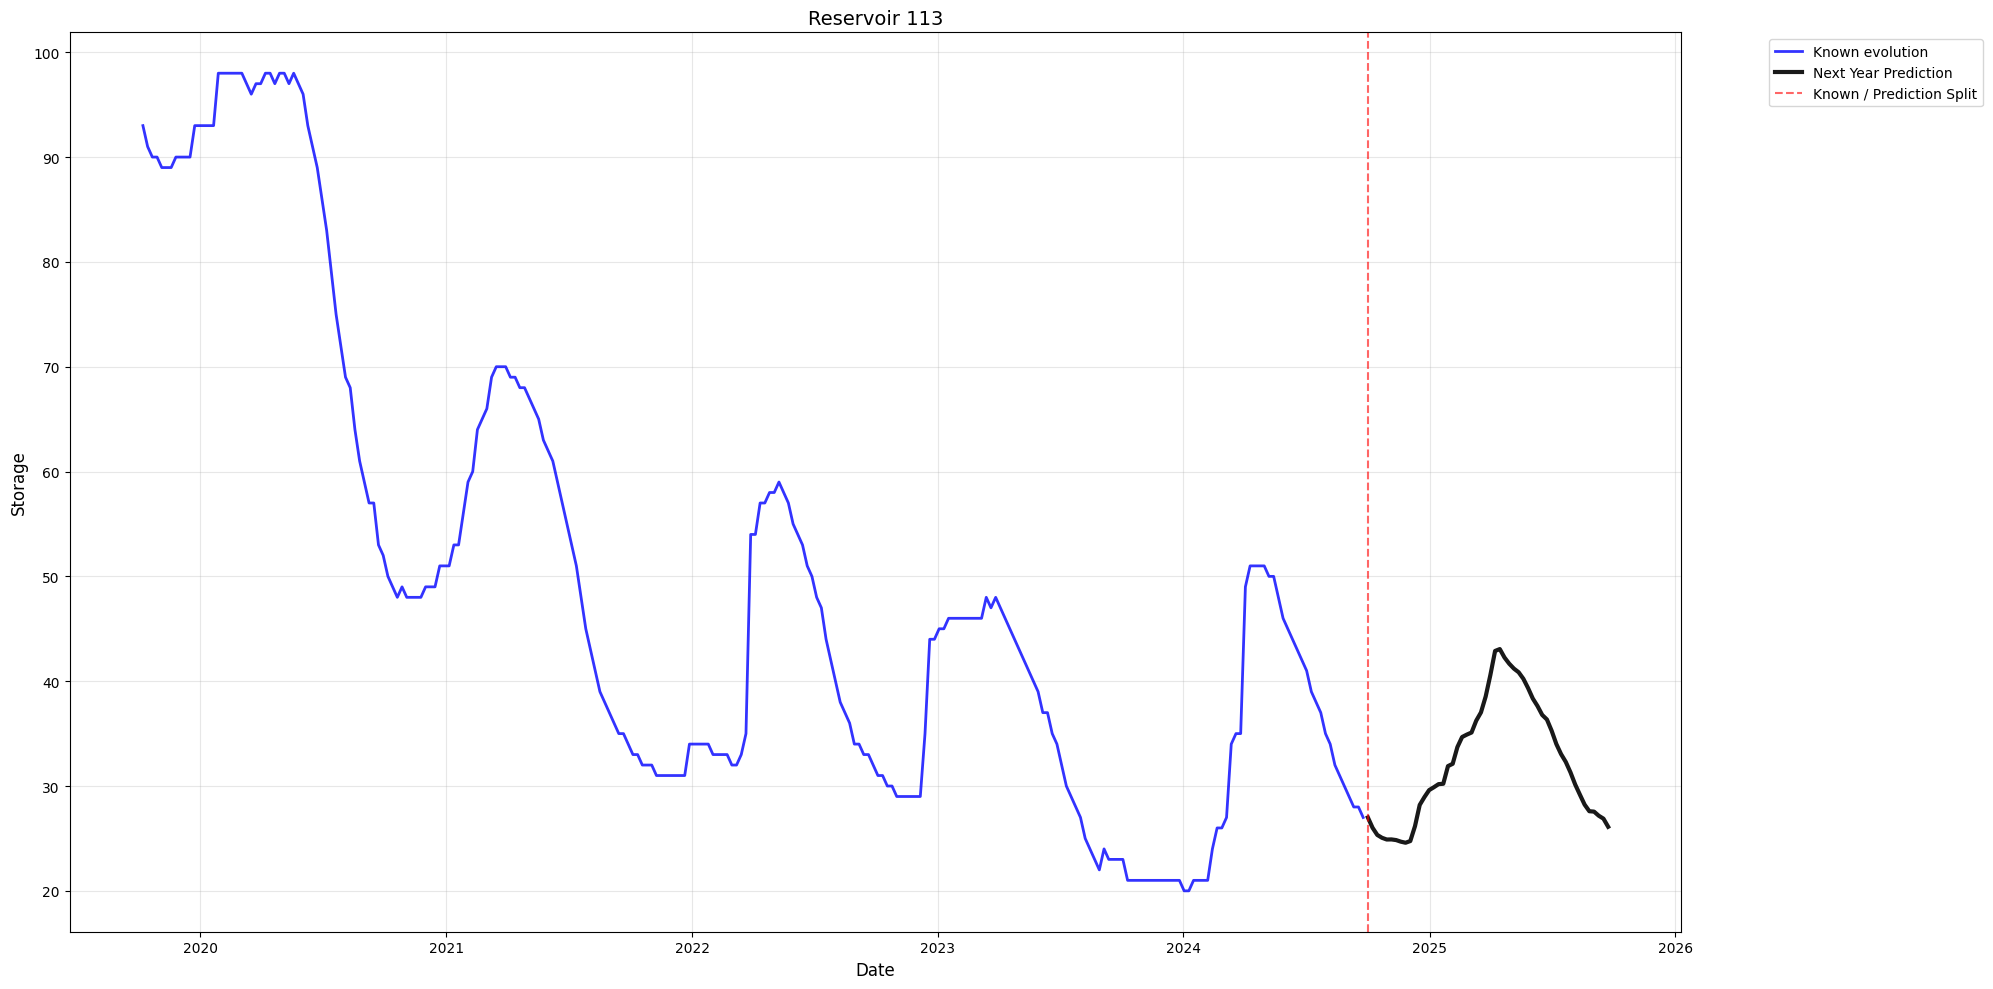

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

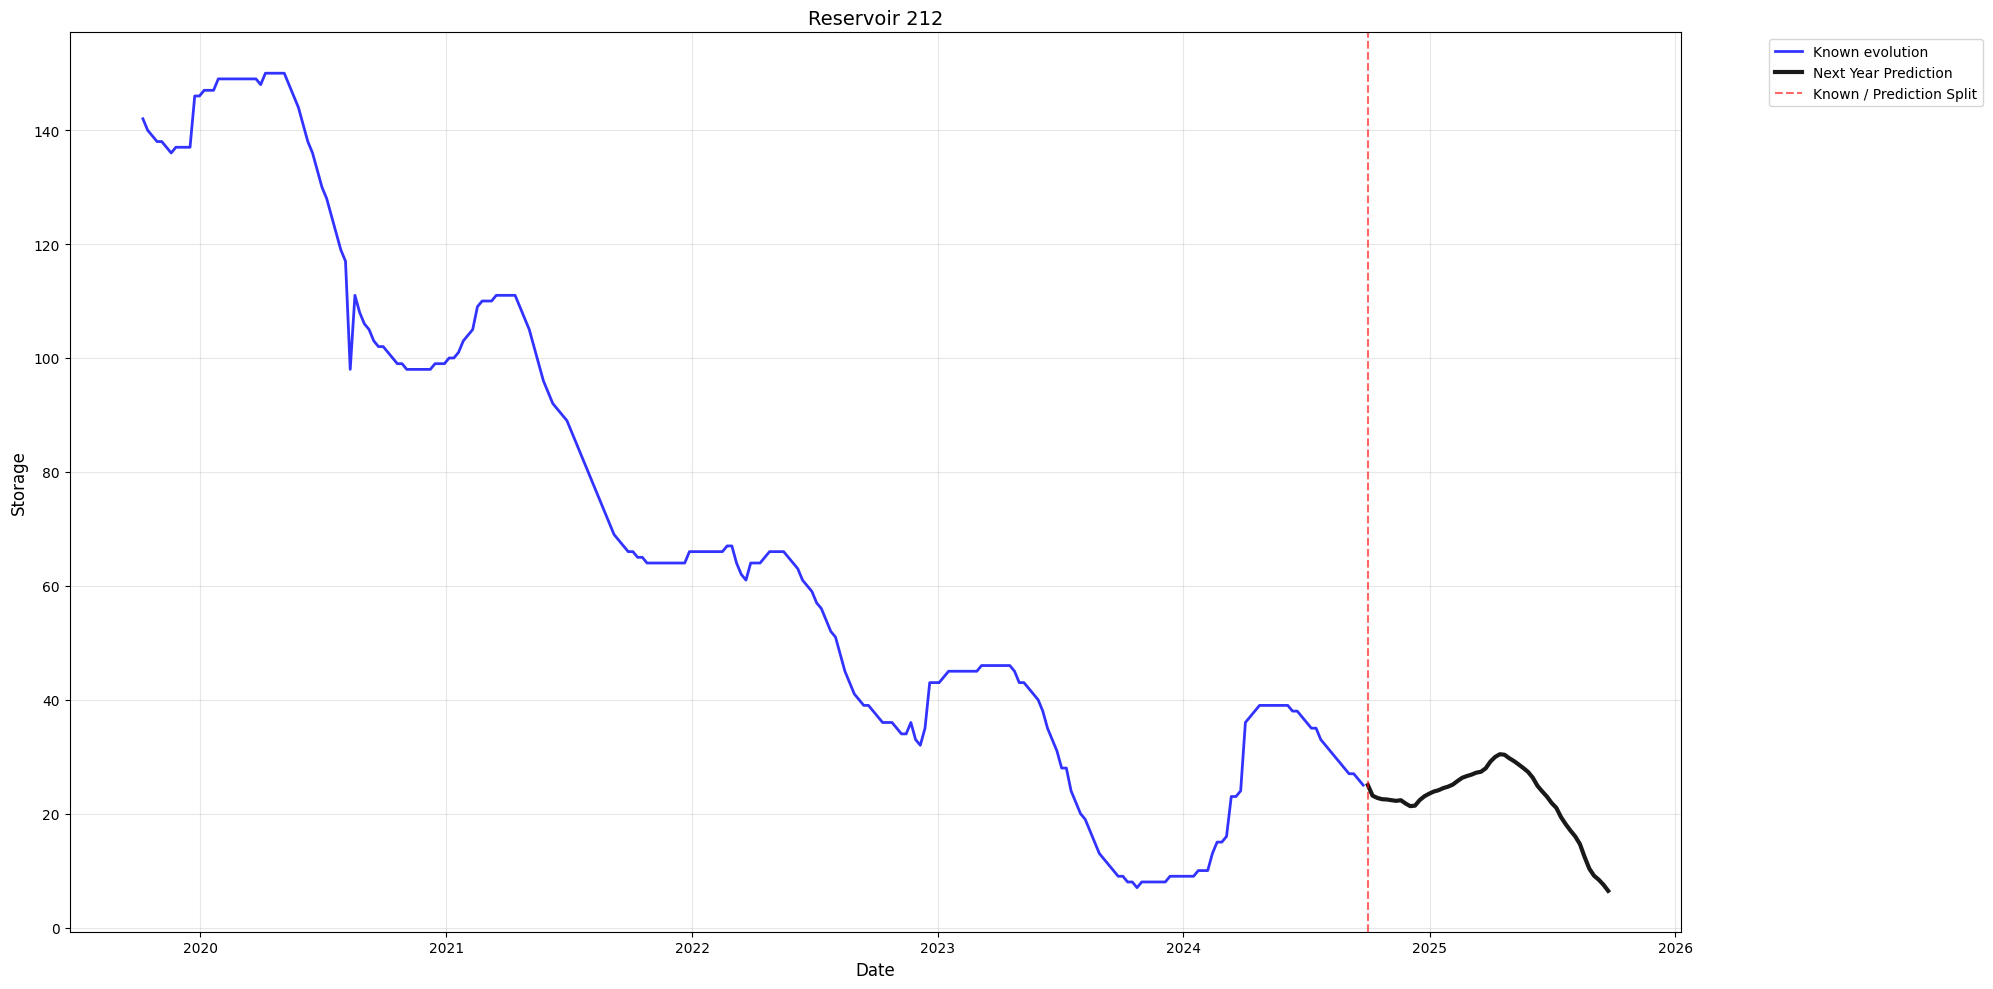

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

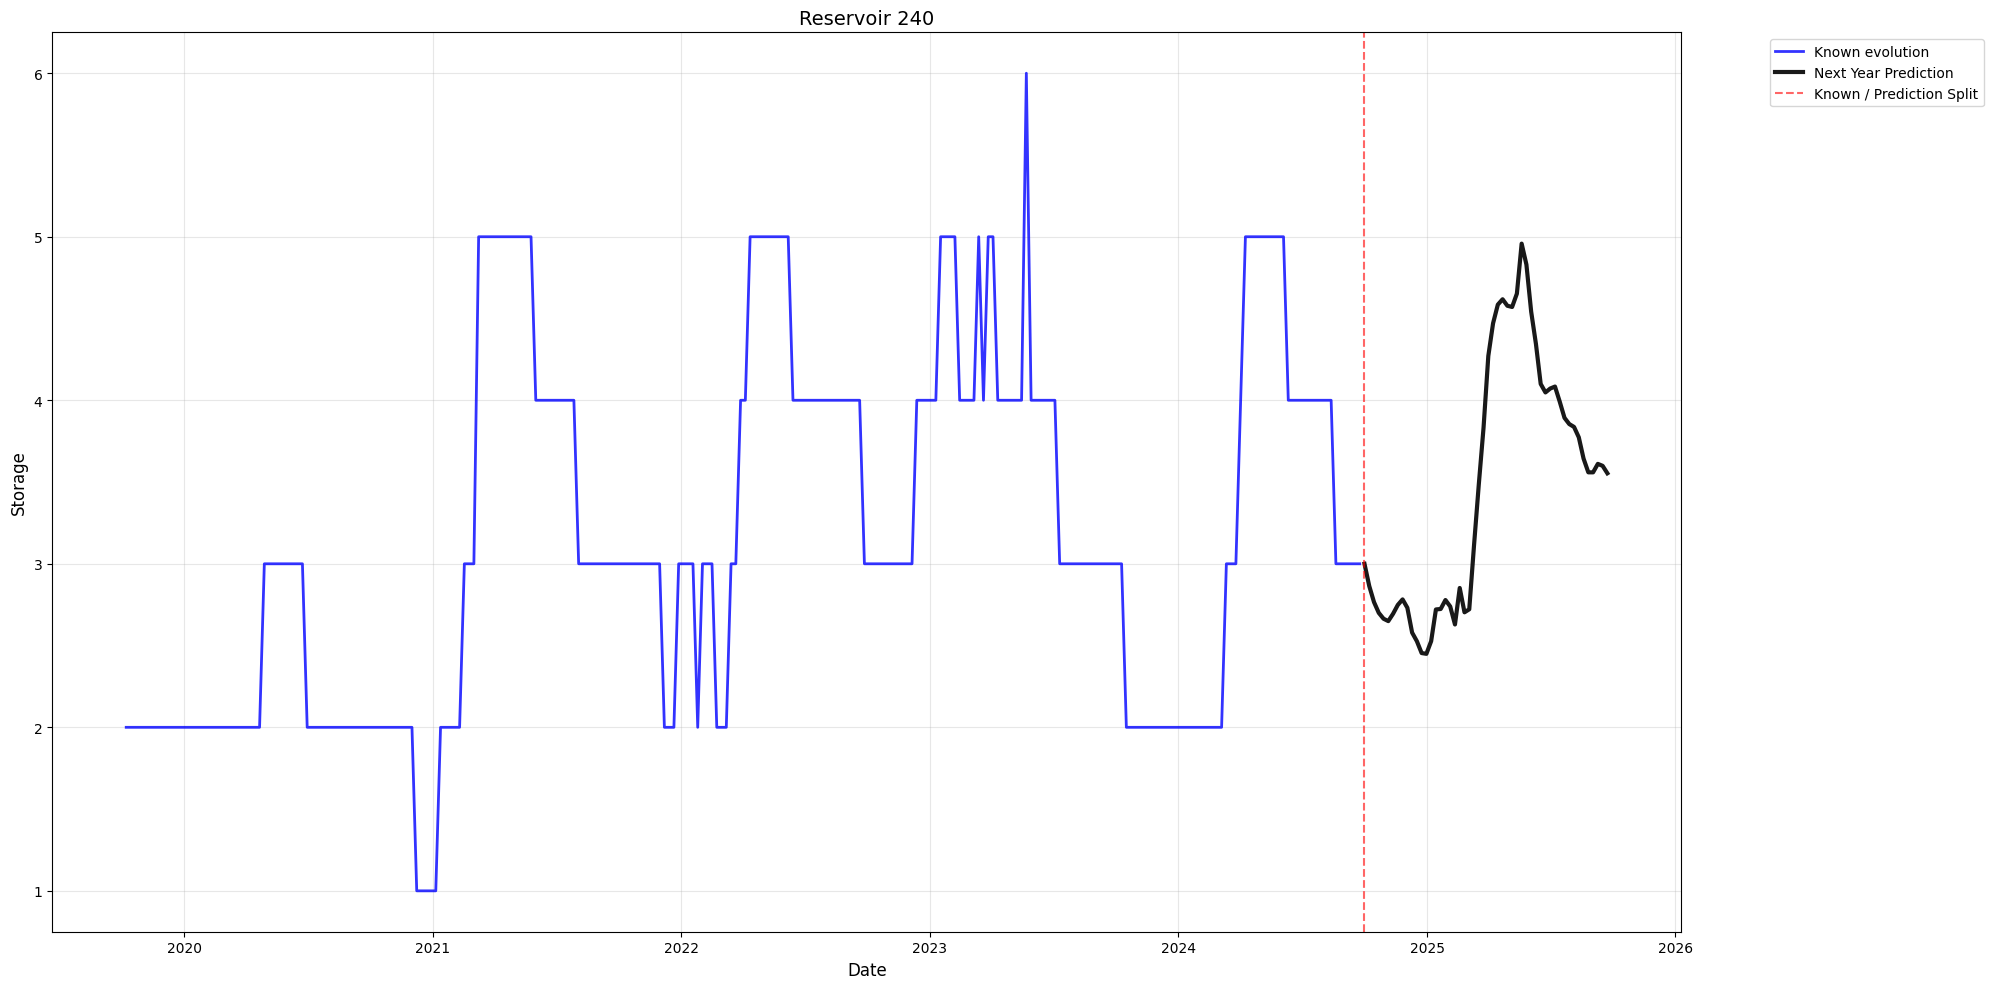

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

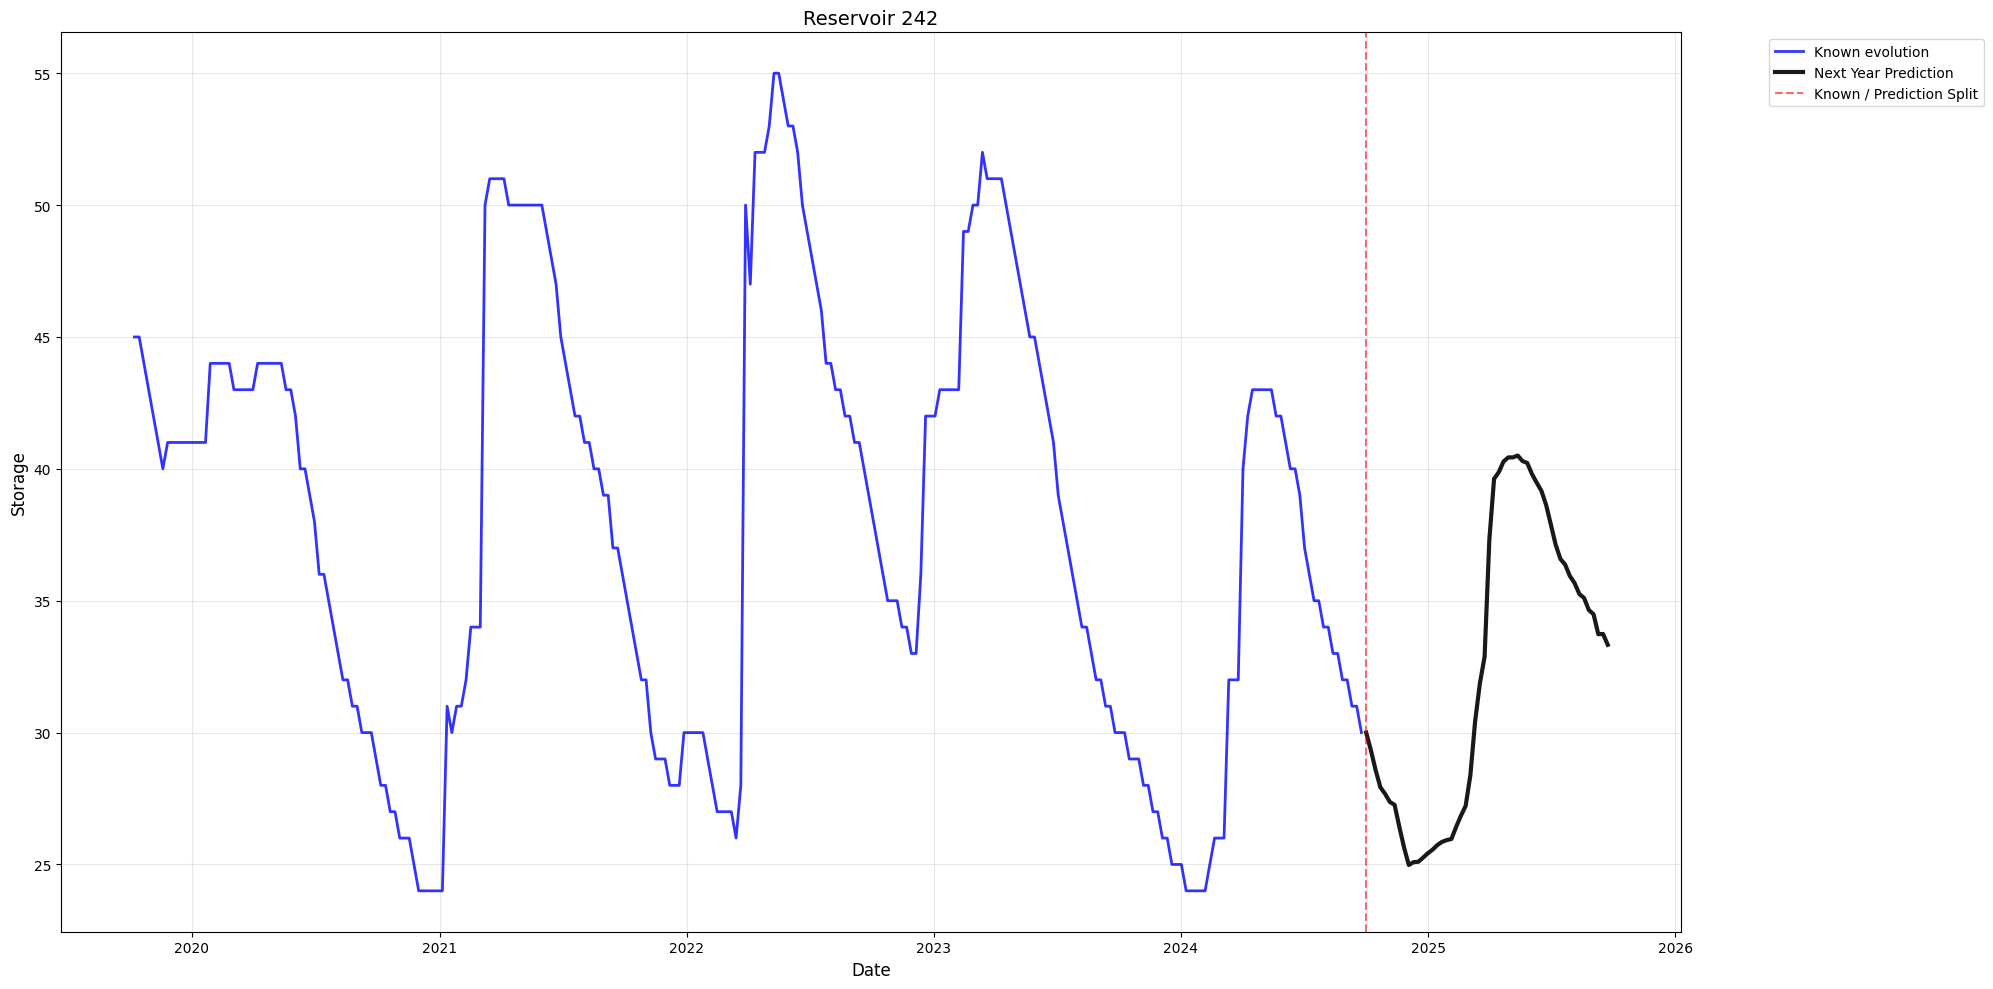

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

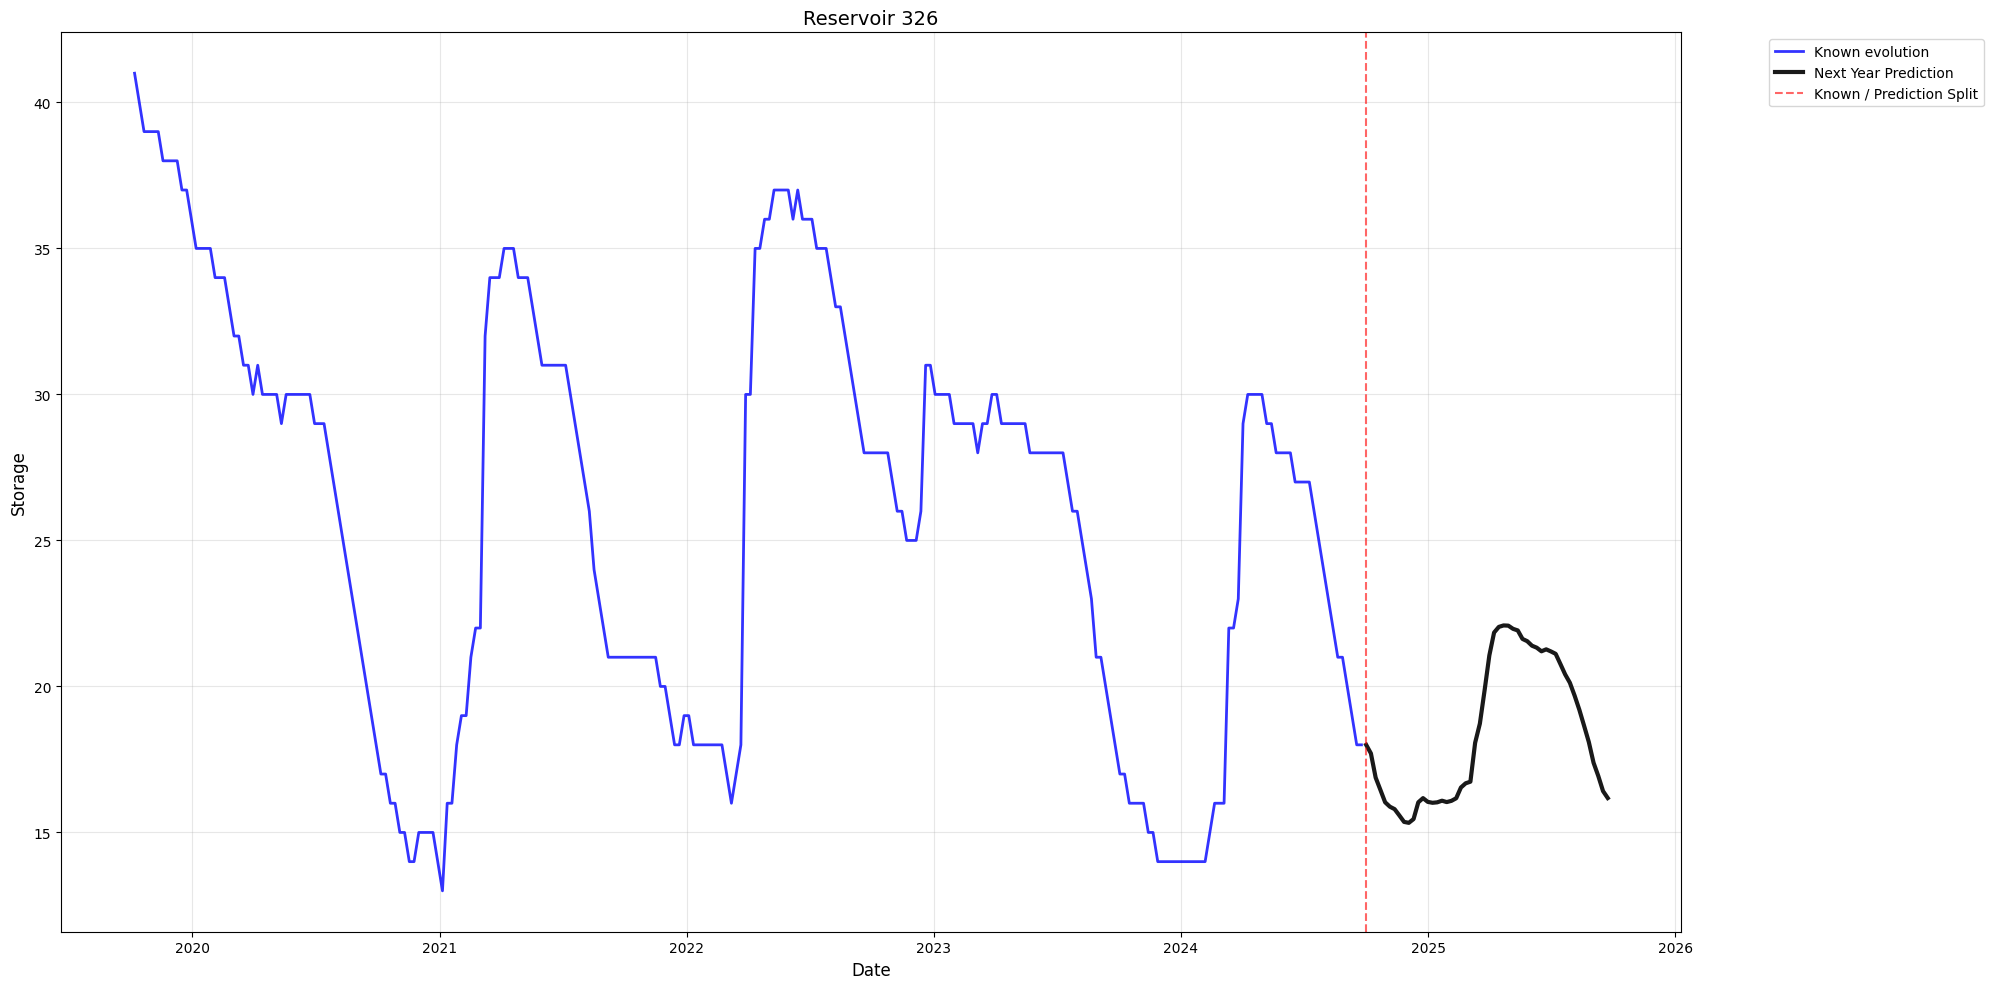

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

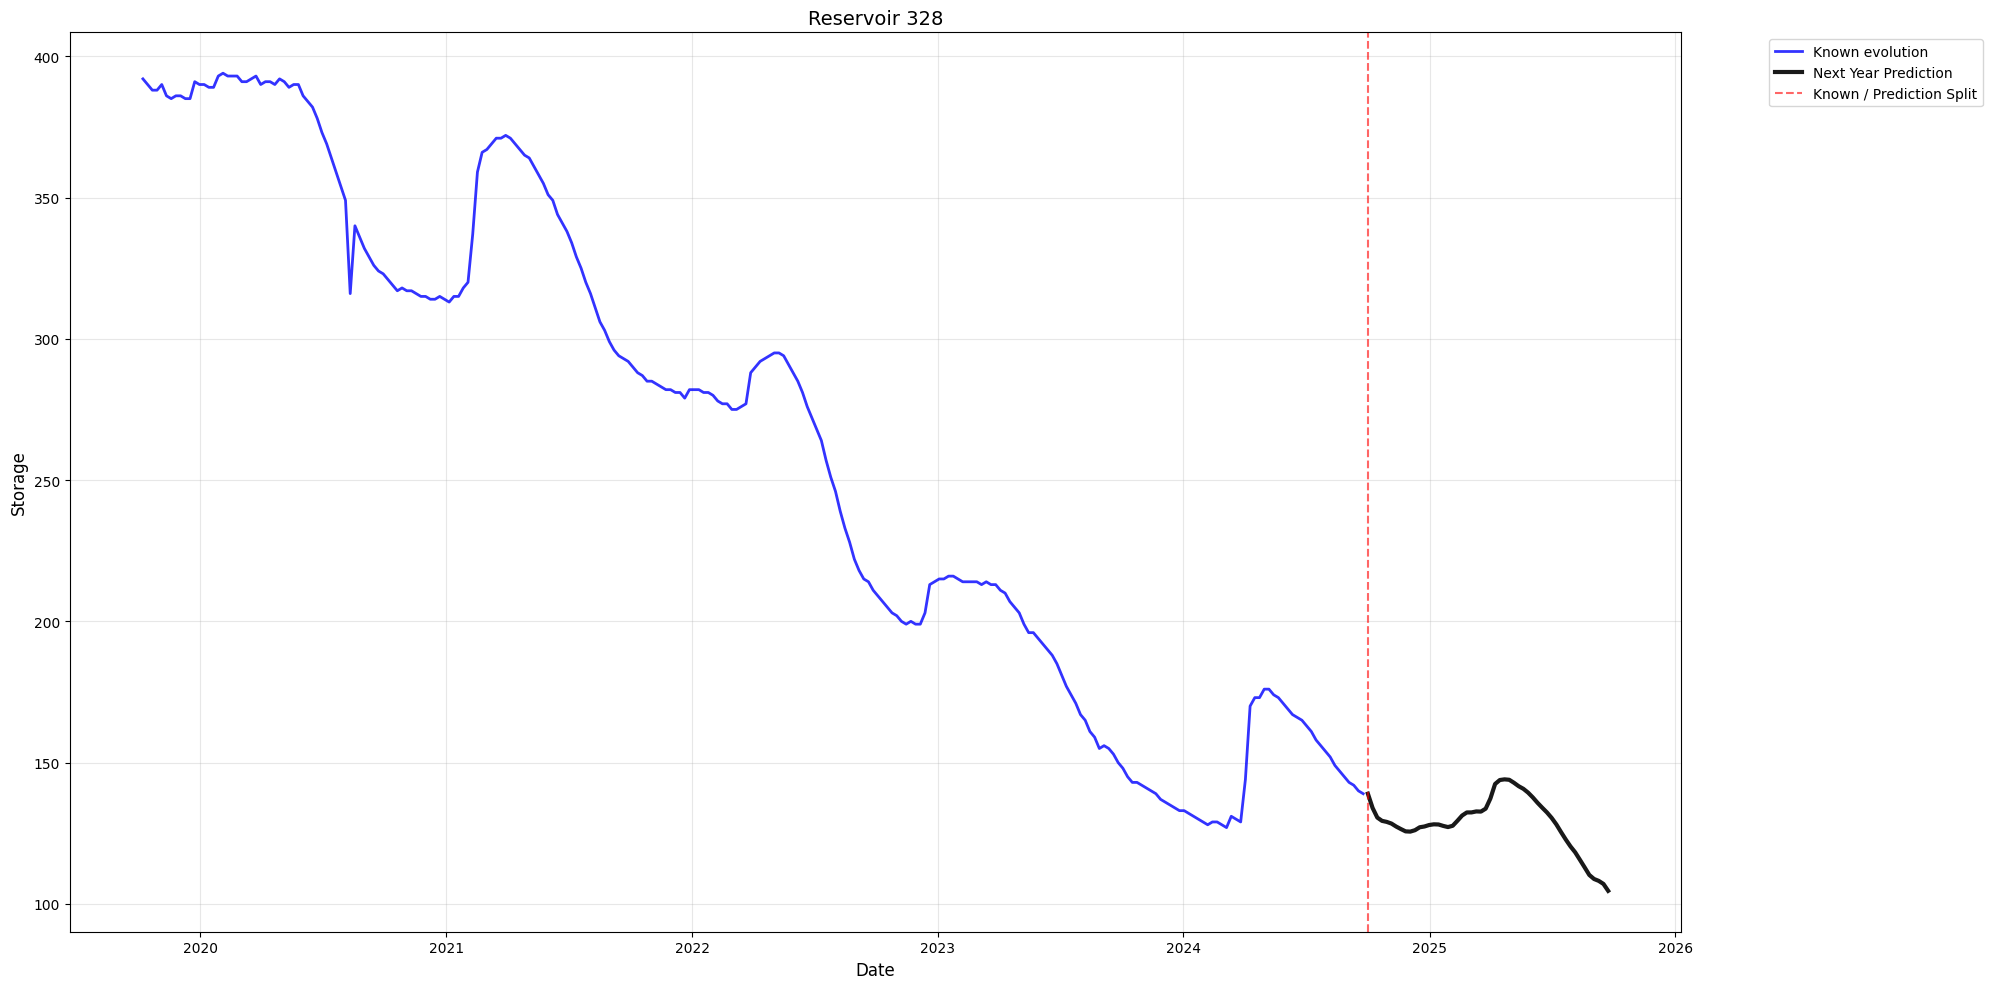

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

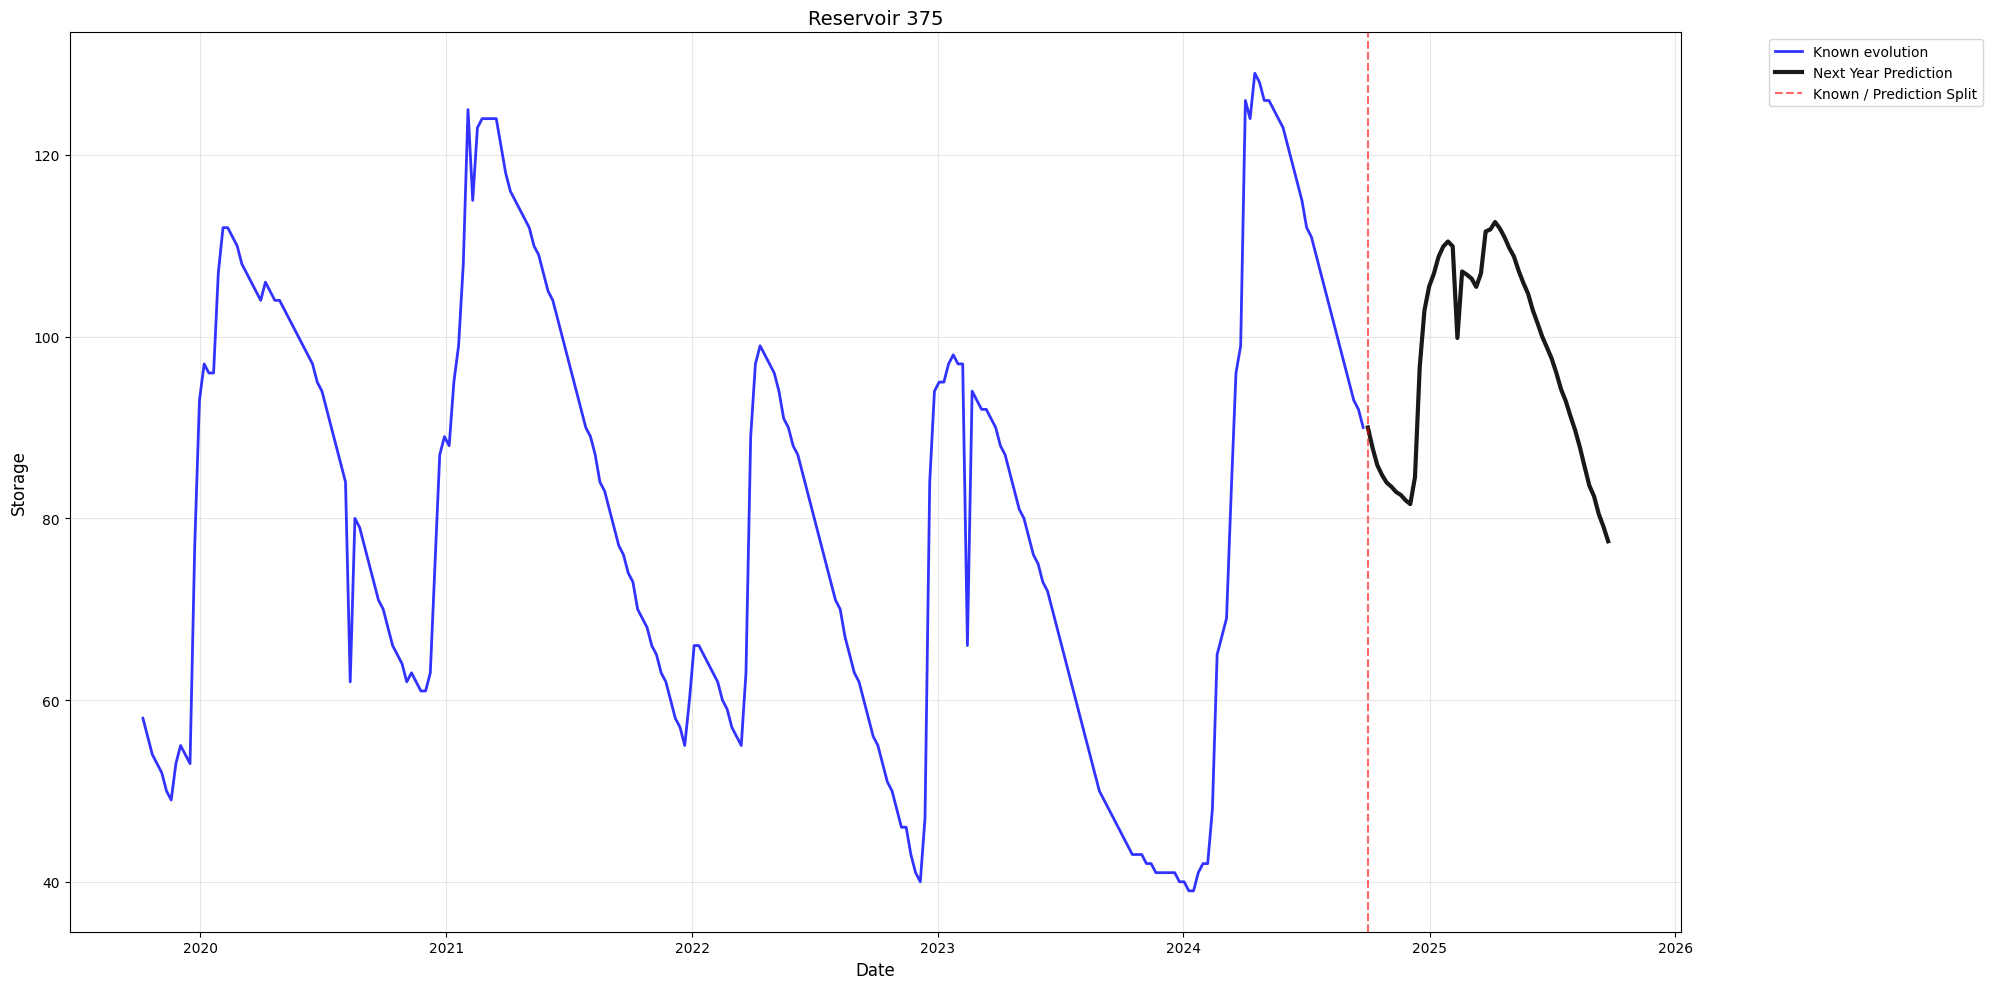

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

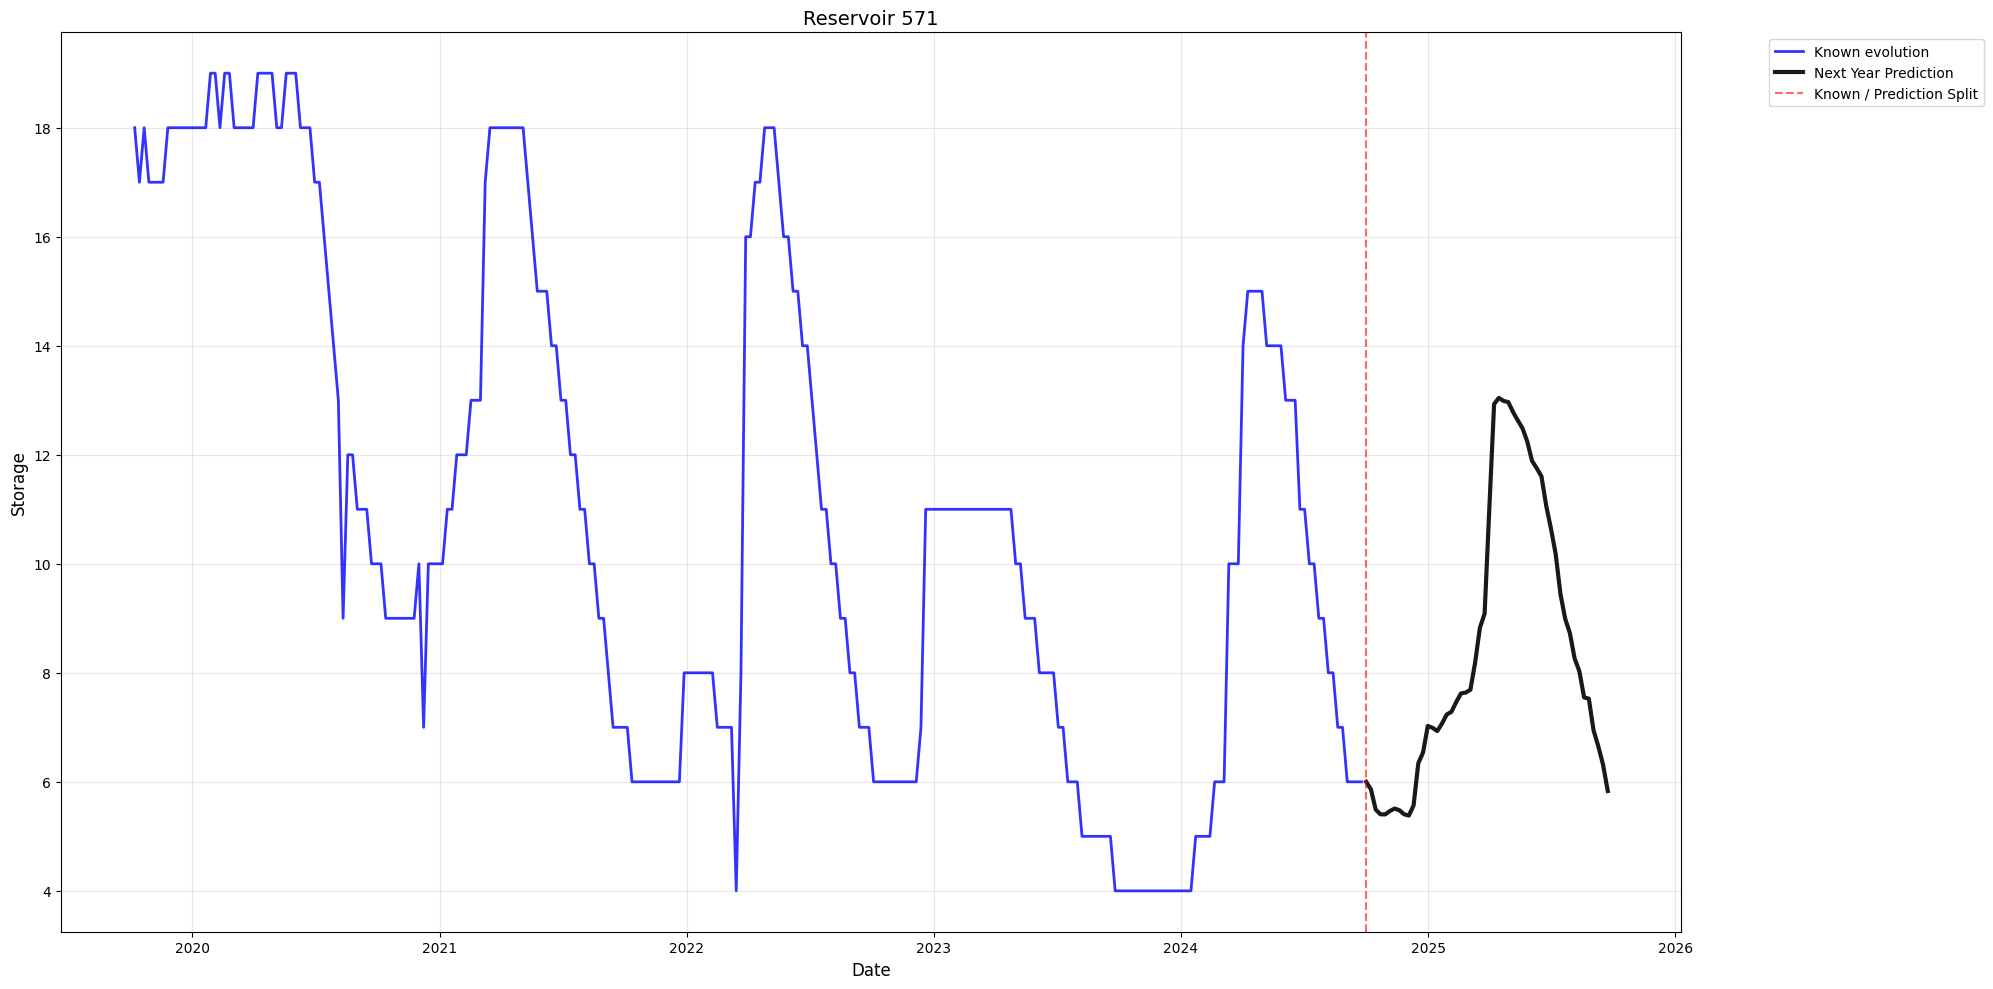

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

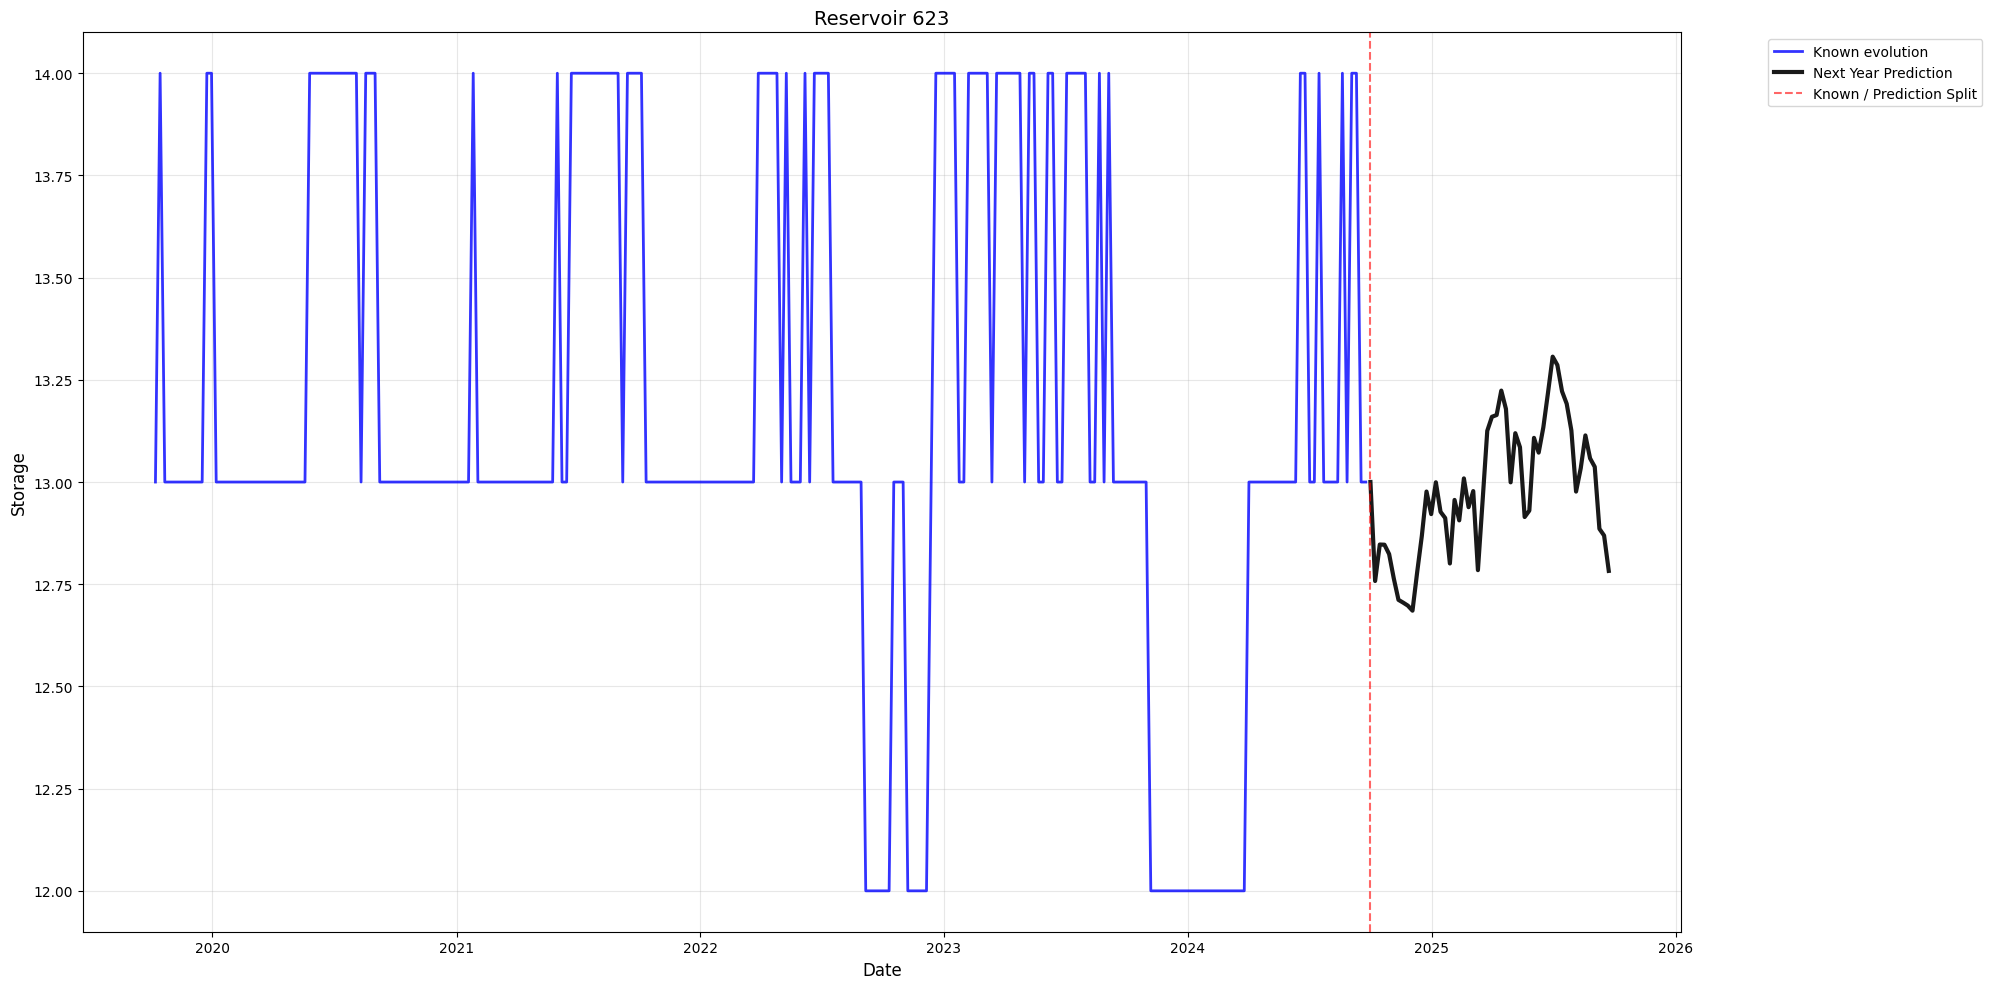

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

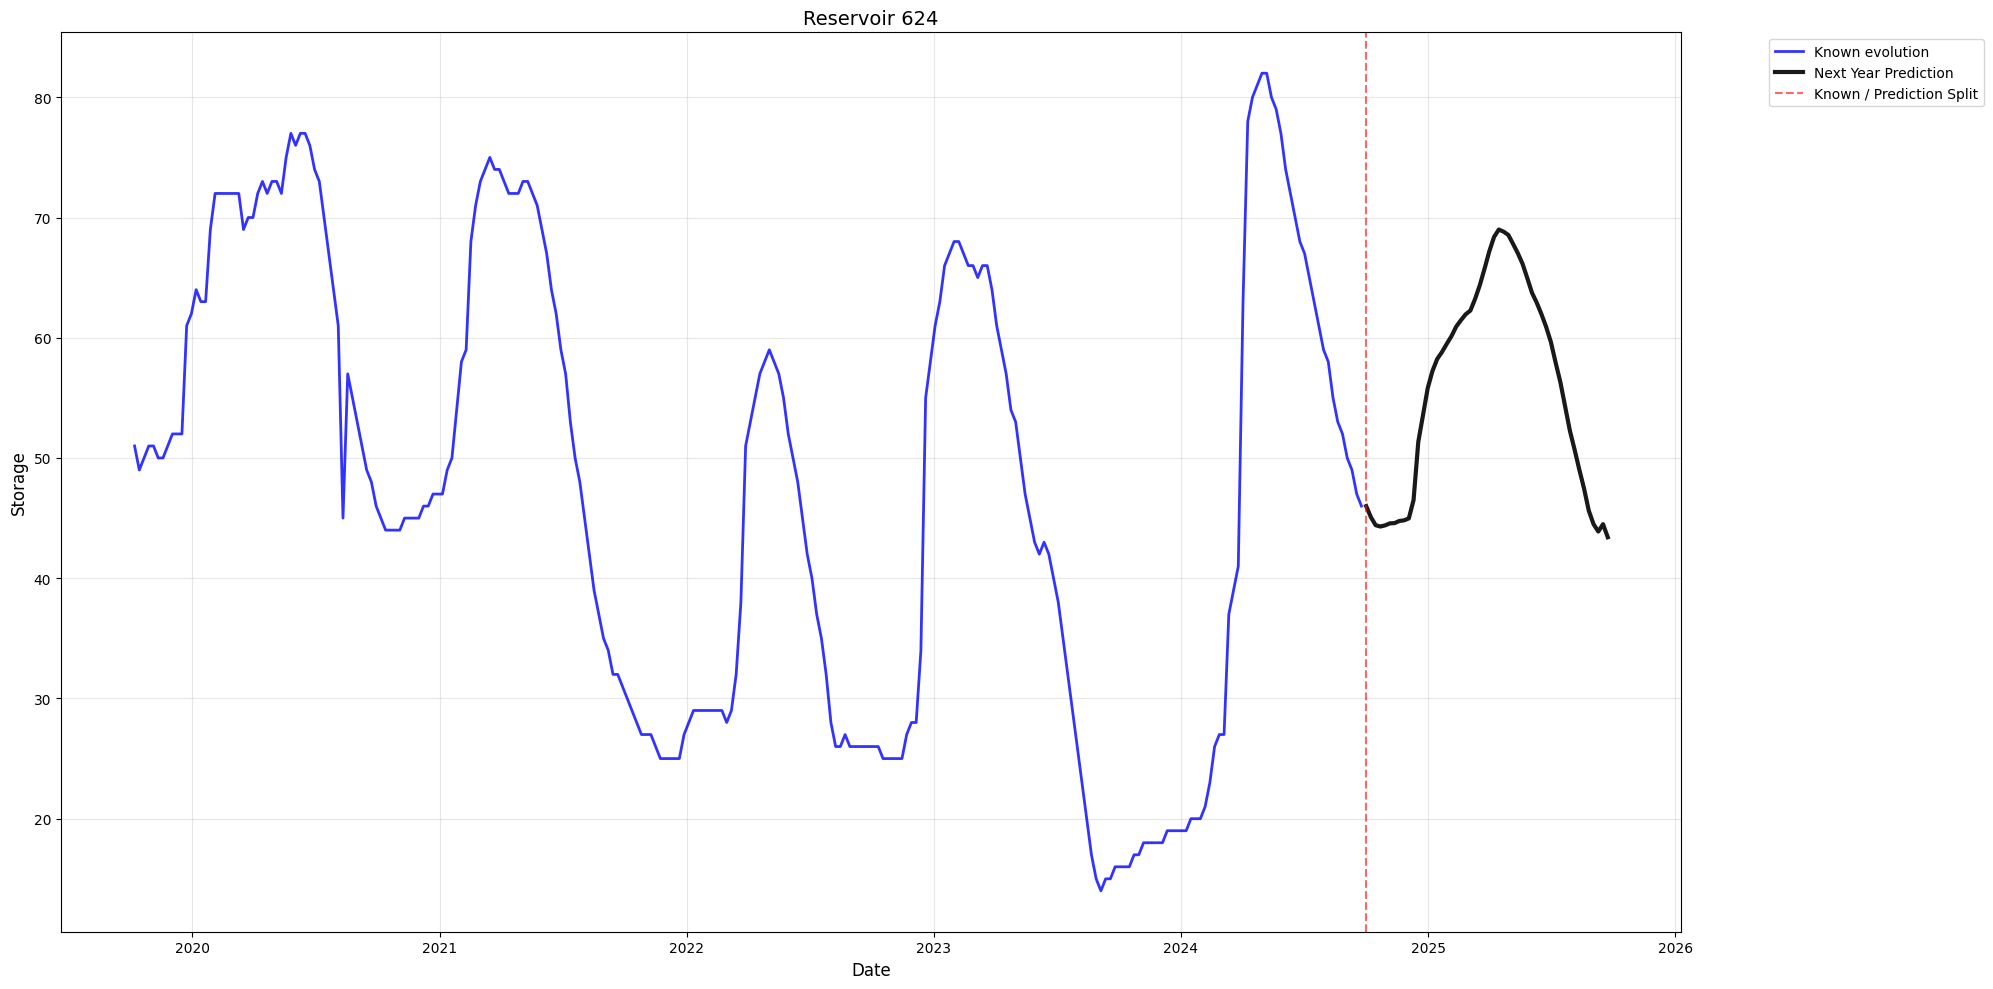

In [97]:
years_training = 4
for reservoir_id in df[df['province']=='cadiz']['id'].unique():
    predict_one_year(reservoir_id, years_training)

In [9]:
from backend.transferring.predicting import predict_one_year
predict_one_year(624, 4, plotting=False)

2024-10-01    46.000000
2024-10-08    45.073878
2024-10-15    44.407259
2024-10-22    44.297686
2024-10-29    44.396300
2024-11-05    44.560704
2024-11-12    44.584788
2024-11-19    44.760106
2024-11-26    44.814496
2024-12-03    44.973903
2024-12-10    46.492712
2024-12-17    51.341010
2024-12-24    53.573347
2024-12-31    55.826916
2025-01-07    57.243181
2025-01-14    58.237582
2025-01-21    58.810855
2025-01-28    59.486427
2025-02-04    60.127516
2025-02-11    60.925252
2025-02-18    61.456806
2025-02-25    61.948647
2025-03-04    62.261938
2025-03-11    63.237525
2025-03-18    64.384255
2025-03-25    65.759314
2025-04-01    67.196819
2025-04-08    68.385957
2025-04-15    68.998172
2025-04-22    68.824218
2025-04-29    68.552450
2025-05-06    67.809368
2025-05-13    67.041173
2025-05-20    66.158626
2025-05-27    64.970875
2025-06-03    63.741377
2025-06-10    62.917191
2025-06-17    61.958706
2025-06-24    60.888131
2025-07-01    59.632435
2025-07-08    57.918485
2025-07-15    56

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

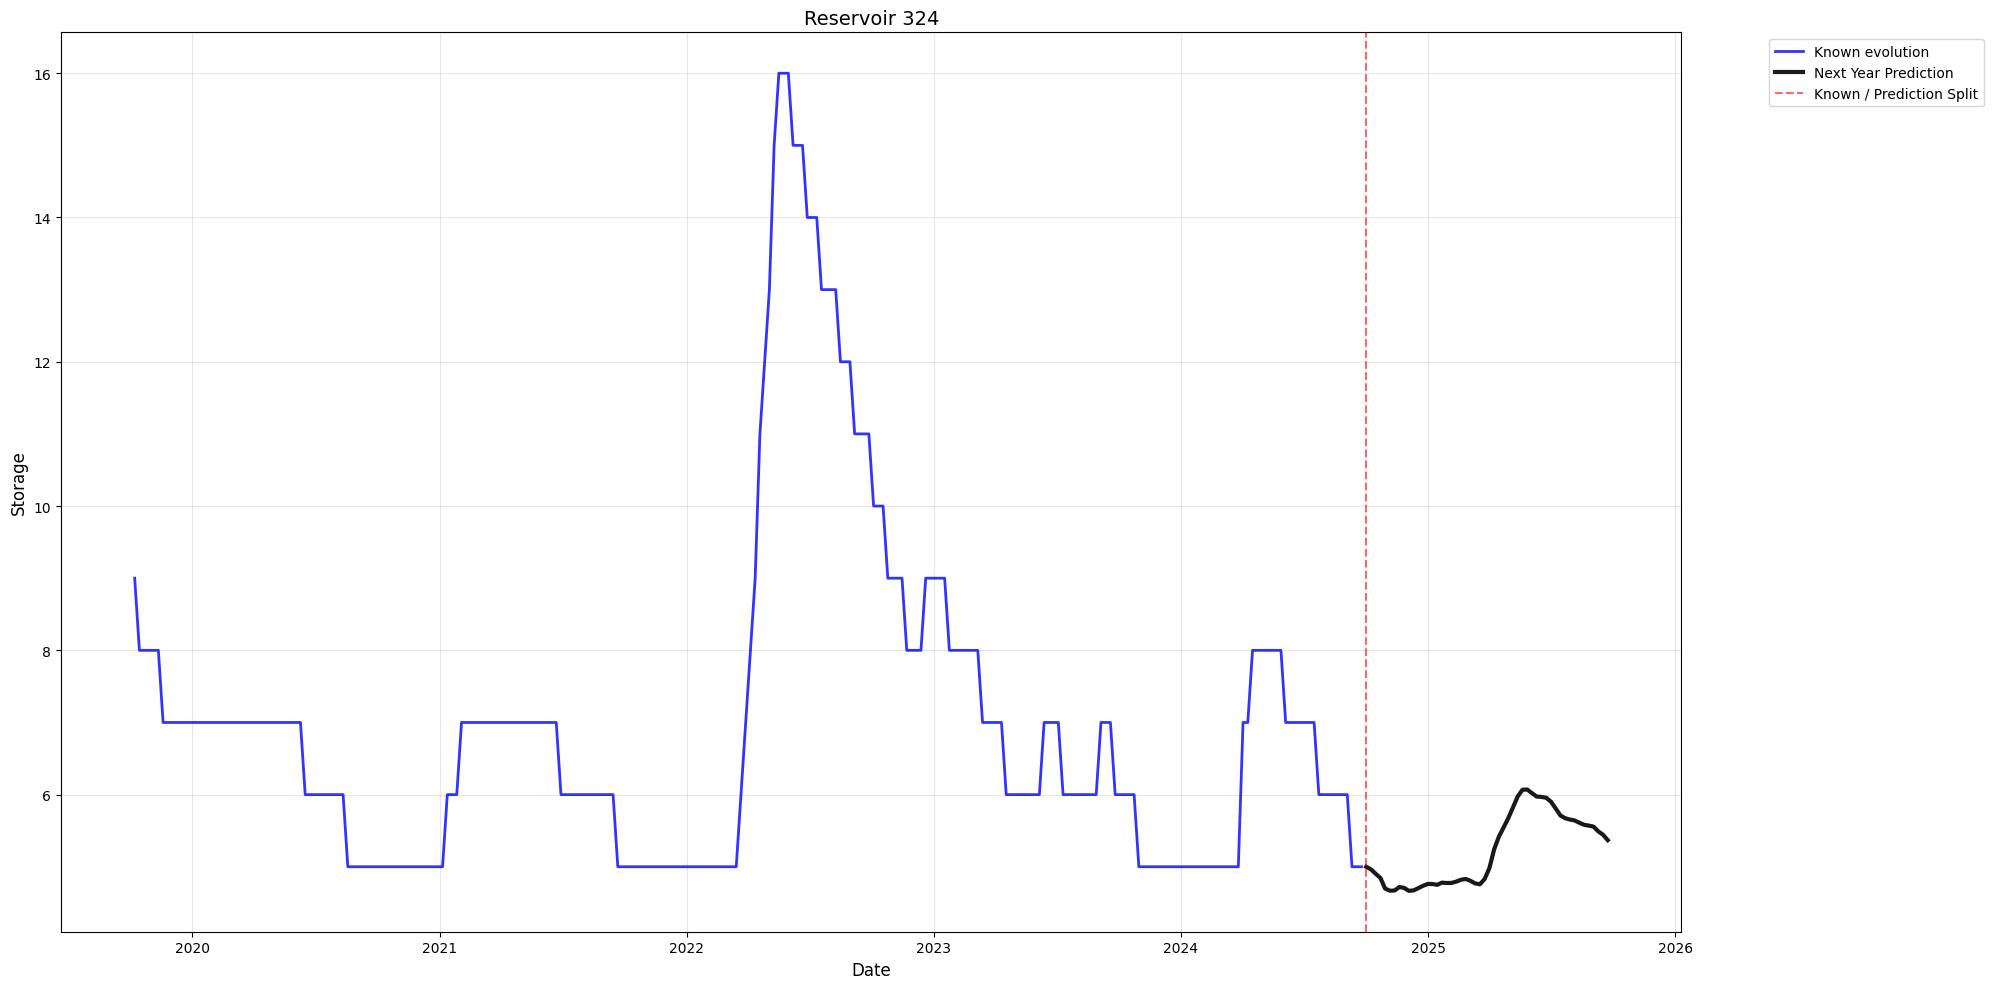

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

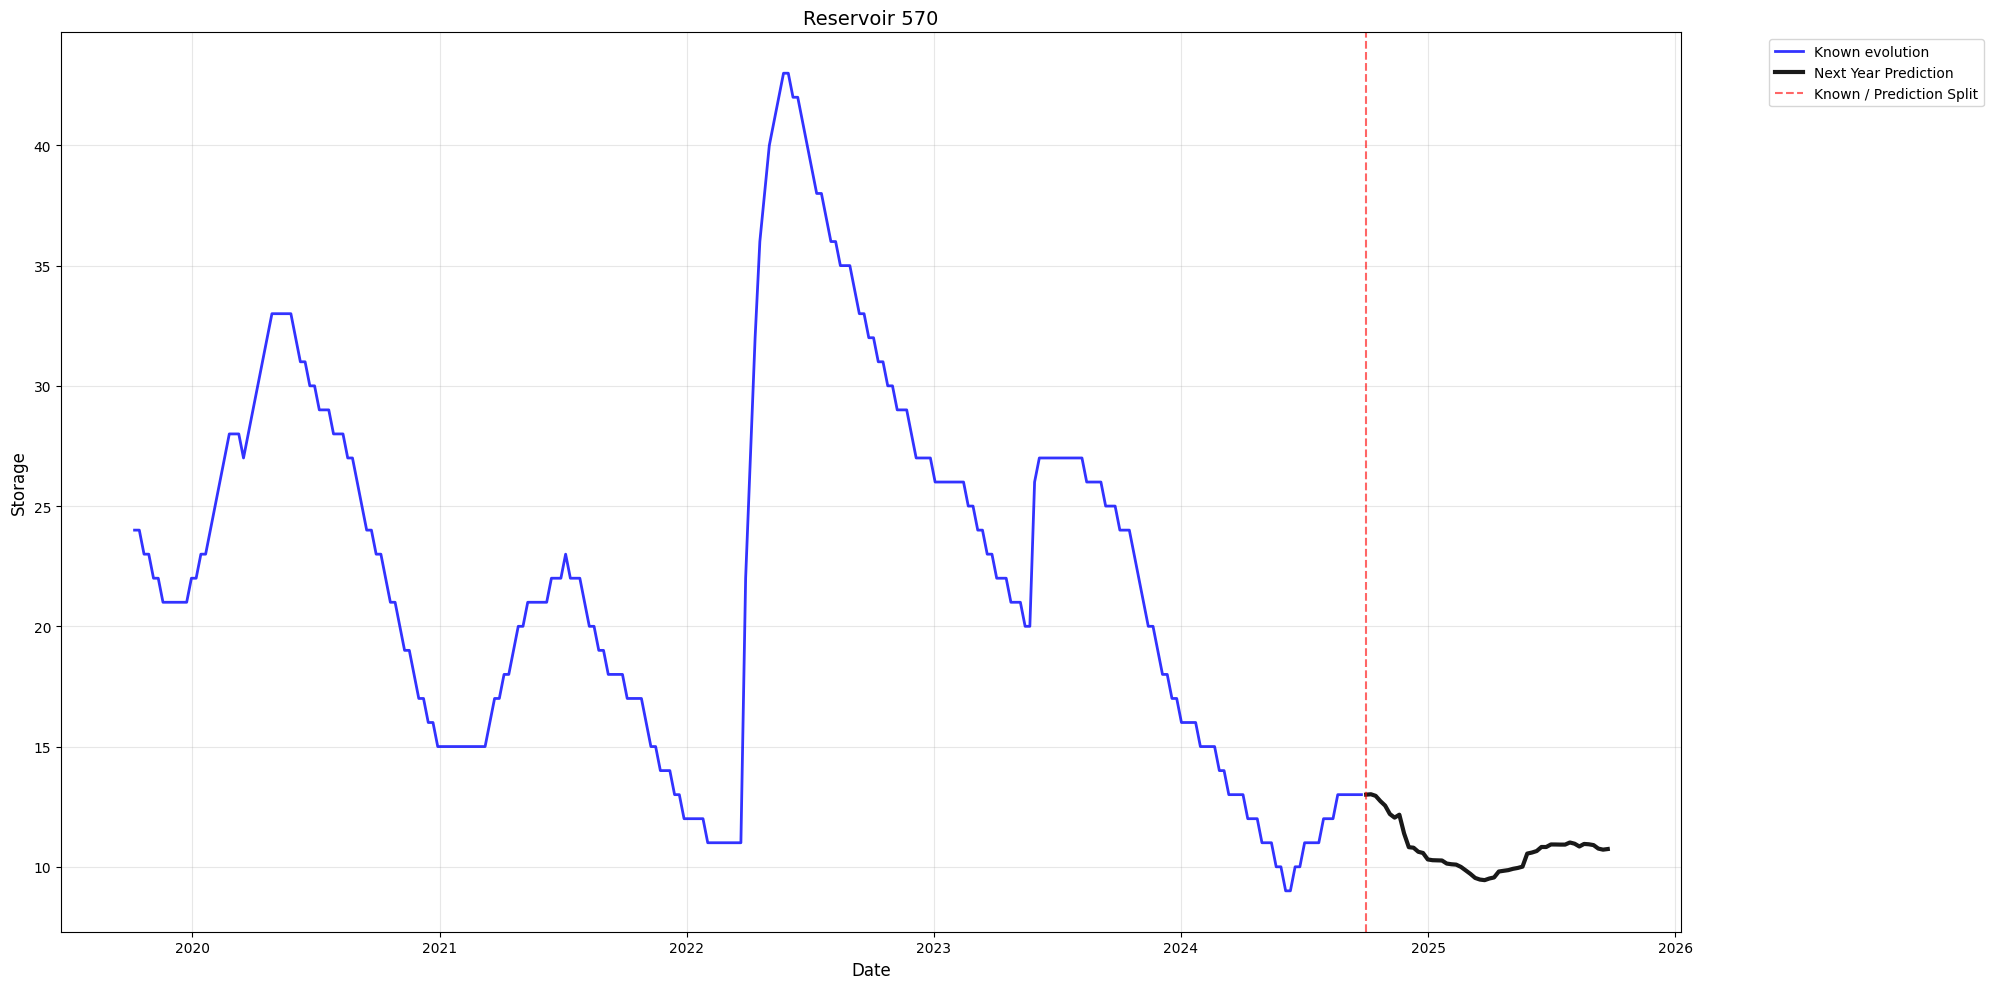

In [12]:
years_training = 4
for reservoir_id in df[df['province']=='almeria']['id'].unique():
    predict_one_year(reservoir_id, years_training)

In [18]:
list(df[df['province']=='cadiz']['id'].unique())

[113, 212, 240, 242, 326, 328, 375, 571, 623, 624]

# Definitive datasets

In [5]:
water_path = PATHS['cleaned_data']/ 'water_cleaned.csv'
water_pd = pd.read_csv(water_path)
water_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683445 entries, 0 to 683444
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     683445 non-null  object
 1   storage  683445 non-null  int64 
 2   id       683445 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 15.6+ MB


In [7]:
water_pd = water_pd[water_pd['id'].isin(reservoirs_2024)]
definitive_path = PATHS['definitive'] / 'water_definitive.csv'
water_pd.to_parquet(definitive_path, index=False)

In [10]:
reservoirs_path = PATHS['cleaned_data']/ 'reservoirs_merged.csv'
reservoirs_pd = pd.read_csv(reservoirs_path)
reservoirs_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    401 non-null    int64  
 1   scope                 401 non-null    object 
 2   name                  401 non-null    object 
 3   capacity              401 non-null    int64  
 4   electric_flag         401 non-null    int64  
 5   latitude              297 non-null    float64
 6   longitude             297 non-null    float64
 7   basin                 297 non-null    object 
 8   riverbed              297 non-null    object 
 9   google                98 non-null     object 
 10  openstreetmap         29 non-null     object 
 11  wikidata              158 non-null    object 
 12  province              401 non-null    object 
 13  autonomous_community  401 non-null    object 
 14  type                  297 non-null    object 
 15  crest_elevation       2

In [11]:
reservoirs_pd = reservoirs_pd[reservoirs_pd['id'].isin(reservoirs_2024)]
definitive_path = PATHS['definitive'] / 'reservoirs_definitive.csv'
reservoirs_pd.to_parquet(definitive_path, index=False)


In [12]:
reservoirs_pd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 1 to 400
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    374 non-null    int64  
 1   scope                 374 non-null    object 
 2   name                  374 non-null    object 
 3   capacity              374 non-null    int64  
 4   electric_flag         374 non-null    int64  
 5   latitude              288 non-null    float64
 6   longitude             288 non-null    float64
 7   basin                 288 non-null    object 
 8   riverbed              288 non-null    object 
 9   google                97 non-null     object 
 10  openstreetmap         29 non-null     object 
 11  wikidata              155 non-null    object 
 12  province              374 non-null    object 
 13  autonomous_community  374 non-null    object 
 14  type                  288 non-null    object 
 15  crest_elevation       288 no